# 🧠 NeuralSOC — CICIDS-2017 Full EDA
**All 5 CSV files | Local Machine | Pre-training Analysis**

---
| File | Day | Key Attacks |
|------|-----|-------------|
| `Monday-WorkingHours.pcap_ISCX.csv` | Monday | BENIGN only |
| `Tuesday-WorkingHours.pcap_ISCX.csv` | Tuesday | FTP-Patator, SSH-Patator |
| `Wednesday-workingHours.pcap_ISCX.csv` | Wednesday | DoS/DDoS, Heartbleed |
| `Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv` | Thursday AM | Web Attacks |
| `Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv` | Thursday PM | Infiltration |
| `Friday-WorkingHours-Morning.pcap_ISCX.csv` | Friday AM | PortScan |
| `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv` | Friday PM | DDoS |
| `Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv` | Friday PM | PortScan |

> ⚙️ **Note:** Set `DATA_DIR` in Cell 2 to your local folder containing the CSVs.

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/friday.csv")
df.shape

(547557, 89)

In [ ]:
import pandas as pd
import os

DATA_DIR   = "../data/raw/"
OUTPUT_DIR = os.path.join(DATA_DIR, "split")
os.makedirs(OUTPUT_DIR, exist_ok=True)

ORIGINALS = {
    "Monday"    : "monday.csv",
    "Tuesday"   : "tuesday.csv",
    "Wednesday" : "wednesday.csv",
    "Thursday"  : "thursday.csv",
    "Friday"    : "friday.csv",
}

def get_label_col(df):
    for col in df.columns:
        if col.strip() == "Label":
            return col
    raise KeyError("No 'Label' column found: " + str(df.columns.tolist()))

# ── PASSTHROUGH DAYS ─────────────────────────────────────────────────────────
for key in ["Monday", "Tuesday", "Wednesday"]:
    src = os.path.join(DATA_DIR, ORIGINALS[key])
    dst = os.path.join(OUTPUT_DIR, ORIGINALS[key])
    print(f"[{key}] Loading...")
    df = pd.read_csv(src, low_memory=False)
    df.to_csv(dst, index=False)
    print(f"  ✓ {len(df):,} rows → {os.path.basename(dst)}")

# ── THURSDAY SPLIT ───────────────────────────────────────────────────────────
print("\n[Thursday] Loading...")
thu = pd.read_csv(os.path.join(DATA_DIR, ORIGINALS["Thursday"]), low_memory=False)
LABEL = get_label_col(thu)
labels_thu = thu[LABEL].str.strip().unique().tolist()
print(f"  Actual labels: {labels_thu}")

# Match whatever hyphen/dash variant is actually in the file
WEB_LABELS  = {l for l in labels_thu if 'Web Attack' in l}
INF_LABELS  = {l for l in labels_thu if 'Infiltration' in l}
print(f"  Web labels matched: {WEB_LABELS}")
print(f"  Inf labels matched: {INF_LABELS}")

thu_web = thu[thu[LABEL].str.strip().isin(WEB_LABELS | {"BENIGN"})]
thu_inf = thu[thu[LABEL].str.strip().isin(INF_LABELS | {"BENIGN"})]

thu_web.to_csv(os.path.join(OUTPUT_DIR, "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"), index=False)
thu_inf.to_csv(os.path.join(OUTPUT_DIR, "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv"), index=False)
print(f"  ✓ Web Attacks (Morning):    {len(thu_web):,} rows")
print(f"  ✓ Infiltration (Afternoon): {len(thu_inf):,} rows")

# ── FRIDAY SPLIT ─────────────────────────────────────────────────────────────
print("\n[Friday] Loading...")
fri = pd.read_csv(os.path.join(DATA_DIR, ORIGINALS["Friday"]), low_memory=False)
LABEL = get_label_col(fri)
labels_fri = fri[LABEL].str.strip().unique().tolist()
print(f"  Actual labels: {labels_fri}")

port_rows  = fri[fri[LABEL].str.strip().str.contains("PortScan", case=False, na=False)]
benign_rows = fri[fri[LABEL].str.strip() == "BENIGN"]
ddos_rows  = fri[fri[LABEL].str.strip().str.contains("DDoS|ddos", case=False, na=False)]

print(f"  PortScan rows found: {len(port_rows):,}")
print(f"  DDoS rows found:     {len(ddos_rows):,}")
print(f"  BENIGN rows found:   {len(benign_rows):,}")

if len(port_rows) > 0:
    mid = len(port_rows) // 2
    port_am, port_pm = port_rows.iloc[:mid], port_rows.iloc[mid:]
    benign_am = benign_rows.iloc[:len(benign_rows)//2]
    benign_pm = benign_rows.iloc[len(benign_rows)//2:]
    fri_morning     = pd.concat([benign_am, port_am])
    fri_ddos_df     = pd.concat([benign_pm, ddos_rows])
    fri_portscan_pm = port_pm
else:
    # No PortScan in friday.csv — put all BENIGN+DDoS in DDoS file, morning gets BENIGN only
    print("  ⚠️  No PortScan in friday.csv — Fri_PortScan will be empty")
    fri_morning     = benign_rows.iloc[:len(benign_rows)//2]
    fri_ddos_df     = pd.concat([benign_rows.iloc[len(benign_rows)//2:], ddos_rows])
    fri_portscan_pm = pd.DataFrame(columns=fri.columns)  # empty

fri_morning.to_csv(os.path.join(OUTPUT_DIR, "Friday-WorkingHours-Morning.pcap_ISCX.csv"), index=False)
fri_ddos_df.to_csv(os.path.join(OUTPUT_DIR, "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"), index=False)
fri_portscan_pm.to_csv(os.path.join(OUTPUT_DIR, "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"), index=False)

print(f"  ✓ Morning:          {len(fri_morning):,} rows")
print(f"  ✓ DDoS Afternoon:   {len(fri_ddos_df):,} rows")
print(f"  ✓ PortScan Afternoon: {len(fri_portscan_pm):,} rows")

print("\n✅ Done →", OUTPUT_DIR)

[Monday] Loading...
  ✓ 371,621 rows → monday.csv
[Tuesday] Loading...
  ✓ 322,078 rows → tuesday.csv
[Wednesday] Loading...
  ✓ 496,640 rows → wednesday.csv

[Thursday] Loading...
  Total rows: 362,075
  Unique labels: ['BENIGN', 'Web Attack - Brute Force - Attempted', 'Web Attack - Brute Force', 'Infiltration - Attempted', 'Infiltration', 'Infiltration - Portscan', 'Web Attack - XSS - Attempted', 'Web Attack - XSS', 'Web Attack - SQL Injection - Attempted', 'Web Attack - SQL Injection']
  ✓ Web Attacks (Morning):      288,171 rows
  ✓ Infiltration (Afternoon):   288,207 rows
  ✓ Morning (PortScan AM):  144,272 rows
  ✓ DDoS Afternoon:         239,416 rows
  ✓ PortScan Afternoon:     0 rows

✅ All 8 files written to: ../data/raw/split


## Cell 1 — Install & Imports

In [26]:
# Run this only once if packages are missing
# !pip install pandas numpy matplotlib seaborn scikit-learn missingno tqdm

import os
import warnings
import json
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='darkgrid', palette='tab10')
COLORS = sns.color_palette('tab10', 15)

print('✅ All imports successful')

✅ All imports successful


## Cell 2 — CONFIG

In [30]:
# ─────────────────────────────────────────────────────────────────
# 🔧 SET YOUR DATA DIRECTORY HERE
DATA_DIR = "../data/raw/split/"   # Windows
# DATA_DIR = "/home/yourname/datasets/CICIDS2017"       # Linux/Mac
# ─────────────────────────────────────────────────────────────────

OUTPUT_DIR = "./eda_outputs"          # All plots/reports saved here
TARGET_COL  = "Label"                  # After stripping whitespace
SAMPLE_SIZE = None                     # None = load full file (fine for local)

# Map each CSV to a readable short name
FILE_MAP = {
    "Monday-WorkingHours.pcap_ISCX.csv"                            : "Mon_Benign",
    "Tuesday-WorkingHours.pcap_ISCX.csv"                           : "Tue_Brute",
    "Wednesday-workingHours.pcap_ISCX.csv"                         : "Wed_DoS",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"       : "Thu_WebAtt",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv"  : "Thu_Infil",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv"                    : "Fri_Morning",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"             : "Fri_DDoS",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"         : "Fri_PortScan",
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Config set. Output → {os.path.abspath(OUTPUT_DIR)}")

✅ Config set. Output → d:\VSC\GitHub\NeuralSOC\notebooks\eda_outputs


## Cell 3 — File Discovery

In [31]:
found_files = {}
missing_files = []

for fname, tag in FILE_MAP.items():
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / (1024**2)
        found_files[tag] = fpath
        print(f"  ✅  [{tag:15s}]  {fname}  ({size_mb:.1f} MB)")
    else:
        missing_files.append(fname)
        print(f"  ❌  MISSING: {fname}")

print(f"\n{len(found_files)} files found, {len(missing_files)} missing")

  ✅  [Mon_Benign     ]  Monday-WorkingHours.pcap_ISCX.csv  (148.2 MB)
  ✅  [Tue_Brute      ]  Tuesday-WorkingHours.pcap_ISCX.csv  (127.4 MB)
  ✅  [Wed_DoS        ]  Wednesday-workingHours.pcap_ISCX.csv  (207.2 MB)
  ✅  [Thu_WebAtt     ]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (113.6 MB)
  ✅  [Thu_Infil      ]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (113.6 MB)
  ✅  [Fri_Morning    ]  Friday-WorkingHours-Morning.pcap_ISCX.csv  (54.7 MB)
  ✅  [Fri_DDoS       ]  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (103.3 MB)
  ✅  [Fri_PortScan   ]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (0.0 MB)

8 files found, 0 missing


In [33]:
thu = pd.read_csv("../data/raw/split/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv", low_memory=False)
print(thu['Label'].str.strip().unique())

import os
for f in os.listdir("../data/raw"):
    print(f)

['BENIGN']
friday.csv
monday.csv
split
thursday.csv
tuesday.csv
wednesday.csv


## Cell 4 — Load & Clean All Files

In [ ]:
def load_and_clean(filepath, tag, nrows=None):
    """Load one CICIDS CSV, strip whitespace, handle inf/nan, return clean df."""
    print(f"\n⏳ Loading [{tag}] ...", end=" ")
    df = pd.read_csv(filepath, nrows=nrows, low_memory=False)

    # Strip leading/trailing whitespace from column names
    df.columns = df.columns.str.strip()

    # Strip label values
    if TARGET_COL in df.columns:
        df[TARGET_COL] = df[TARGET_COL].str.strip()

    raw_rows = len(df)

    # Replace inf/-inf with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Track nulls before dropping
    null_count = df.isnull().sum().sum()
    df.dropna(inplace=True)

    clean_rows = len(df)
    print(f"Done. {raw_rows:,} → {clean_rows:,} rows ({null_count:,} nulls/infs removed)")
    return df


# Load all found files
datasets = {}
for tag, fpath in found_files.items():
    datasets[tag] = load_and_clean(fpath, tag, nrows=SAMPLE_SIZE)

print(f"\n✅ All files loaded. Total tags: {list(datasets.keys())}")


⏳ Loading [Mon_Benign] ... Done. 371,621 → 371,621 rows (0 nulls/infs removed)

⏳ Loading [Tue_Brute] ... Done. 322,078 → 322,078 rows (0 nulls/infs removed)

⏳ Loading [Wed_DoS] ... Done. 496,640 → 496,640 rows (0 nulls/infs removed)

⏳ Loading [Thu_WebAtt] ... Done. 288,171 → 288,171 rows (0 nulls/infs removed)

⏳ Loading [Thu_Infil] ... Done. 288,207 → 288,207 rows (0 nulls/infs removed)

⏳ Loading [Fri_Morning] ... Done. 144,272 → 144,272 rows (0 nulls/infs removed)

⏳ Loading [Fri_DDoS] ... Done. 239,416 → 239,416 rows (0 nulls/infs removed)

⏳ Loading [Fri_PortScan] ... Done. 0 → 0 rows (0 nulls/infs removed)

✅ All files loaded. Total tags: ['Mon_Benign', 'Tue_Brute', 'Wed_DoS', 'Thu_WebAtt', 'Thu_Infil', 'Fri_Morning', 'Fri_DDoS', 'Fri_PortScan']


## Cell 5 — Per-File Summary Table

In [35]:
summary_rows = []

for tag, df in datasets.items():
    label_counts = df[TARGET_COL].value_counts()
    benign = label_counts.get('BENIGN', 0)
    attack = label_counts.sum() - benign
    attack_types = [l for l in label_counts.index if l != 'BENIGN']

    summary_rows.append({
        'File Tag'         : tag,
        'Total Rows'       : len(df),
        'Features'         : df.shape[1] - 1,
        'BENIGN'           : benign,
        'Attack Rows'      : attack,
        'Imbalance Ratio'  : round(benign / max(attack, 1), 2),
        'Attack Types'     : len(attack_types),
        'Attack Labels'    : ', '.join(attack_types[:4]) + ('...' if len(attack_types) > 4 else '')
    })

summary_df = pd.DataFrame(summary_rows)
print("═" * 100)
print(summary_df.to_string(index=False))
print("═" * 100)

# Save summary
summary_df.to_csv(f"{OUTPUT_DIR}/00_dataset_summary.csv", index=False)
print("\n📁 Saved: 00_dataset_summary.csv")

════════════════════════════════════════════════════════════════════════════════════════════════════
    File Tag  Total Rows  Features  BENIGN  Attack Rows  Imbalance Ratio  Attack Types                                                              Attack Labels
  Mon_Benign      371621        88  371621            0      371621.0000             0                                                                           
   Tue_Brute      322078        88  315106         6972          45.2000             4 FTP-Patator, SSH-Patator, SSH-Patator - Attempted, FTP-Patator - Attempted
     Wed_DoS      496640        88  319119       177521           1.8000             9    DoS Hulk, DoS GoldenEye, DoS Slowloris, DoS Slowhttptest - Attempted...
  Thu_WebAtt      288171        88  288171            0      288171.0000             0                                                                           
   Thu_Infil      288207        88  288171           36        8004.7500             1   

## Cell 6 — Class Distribution (All Files)

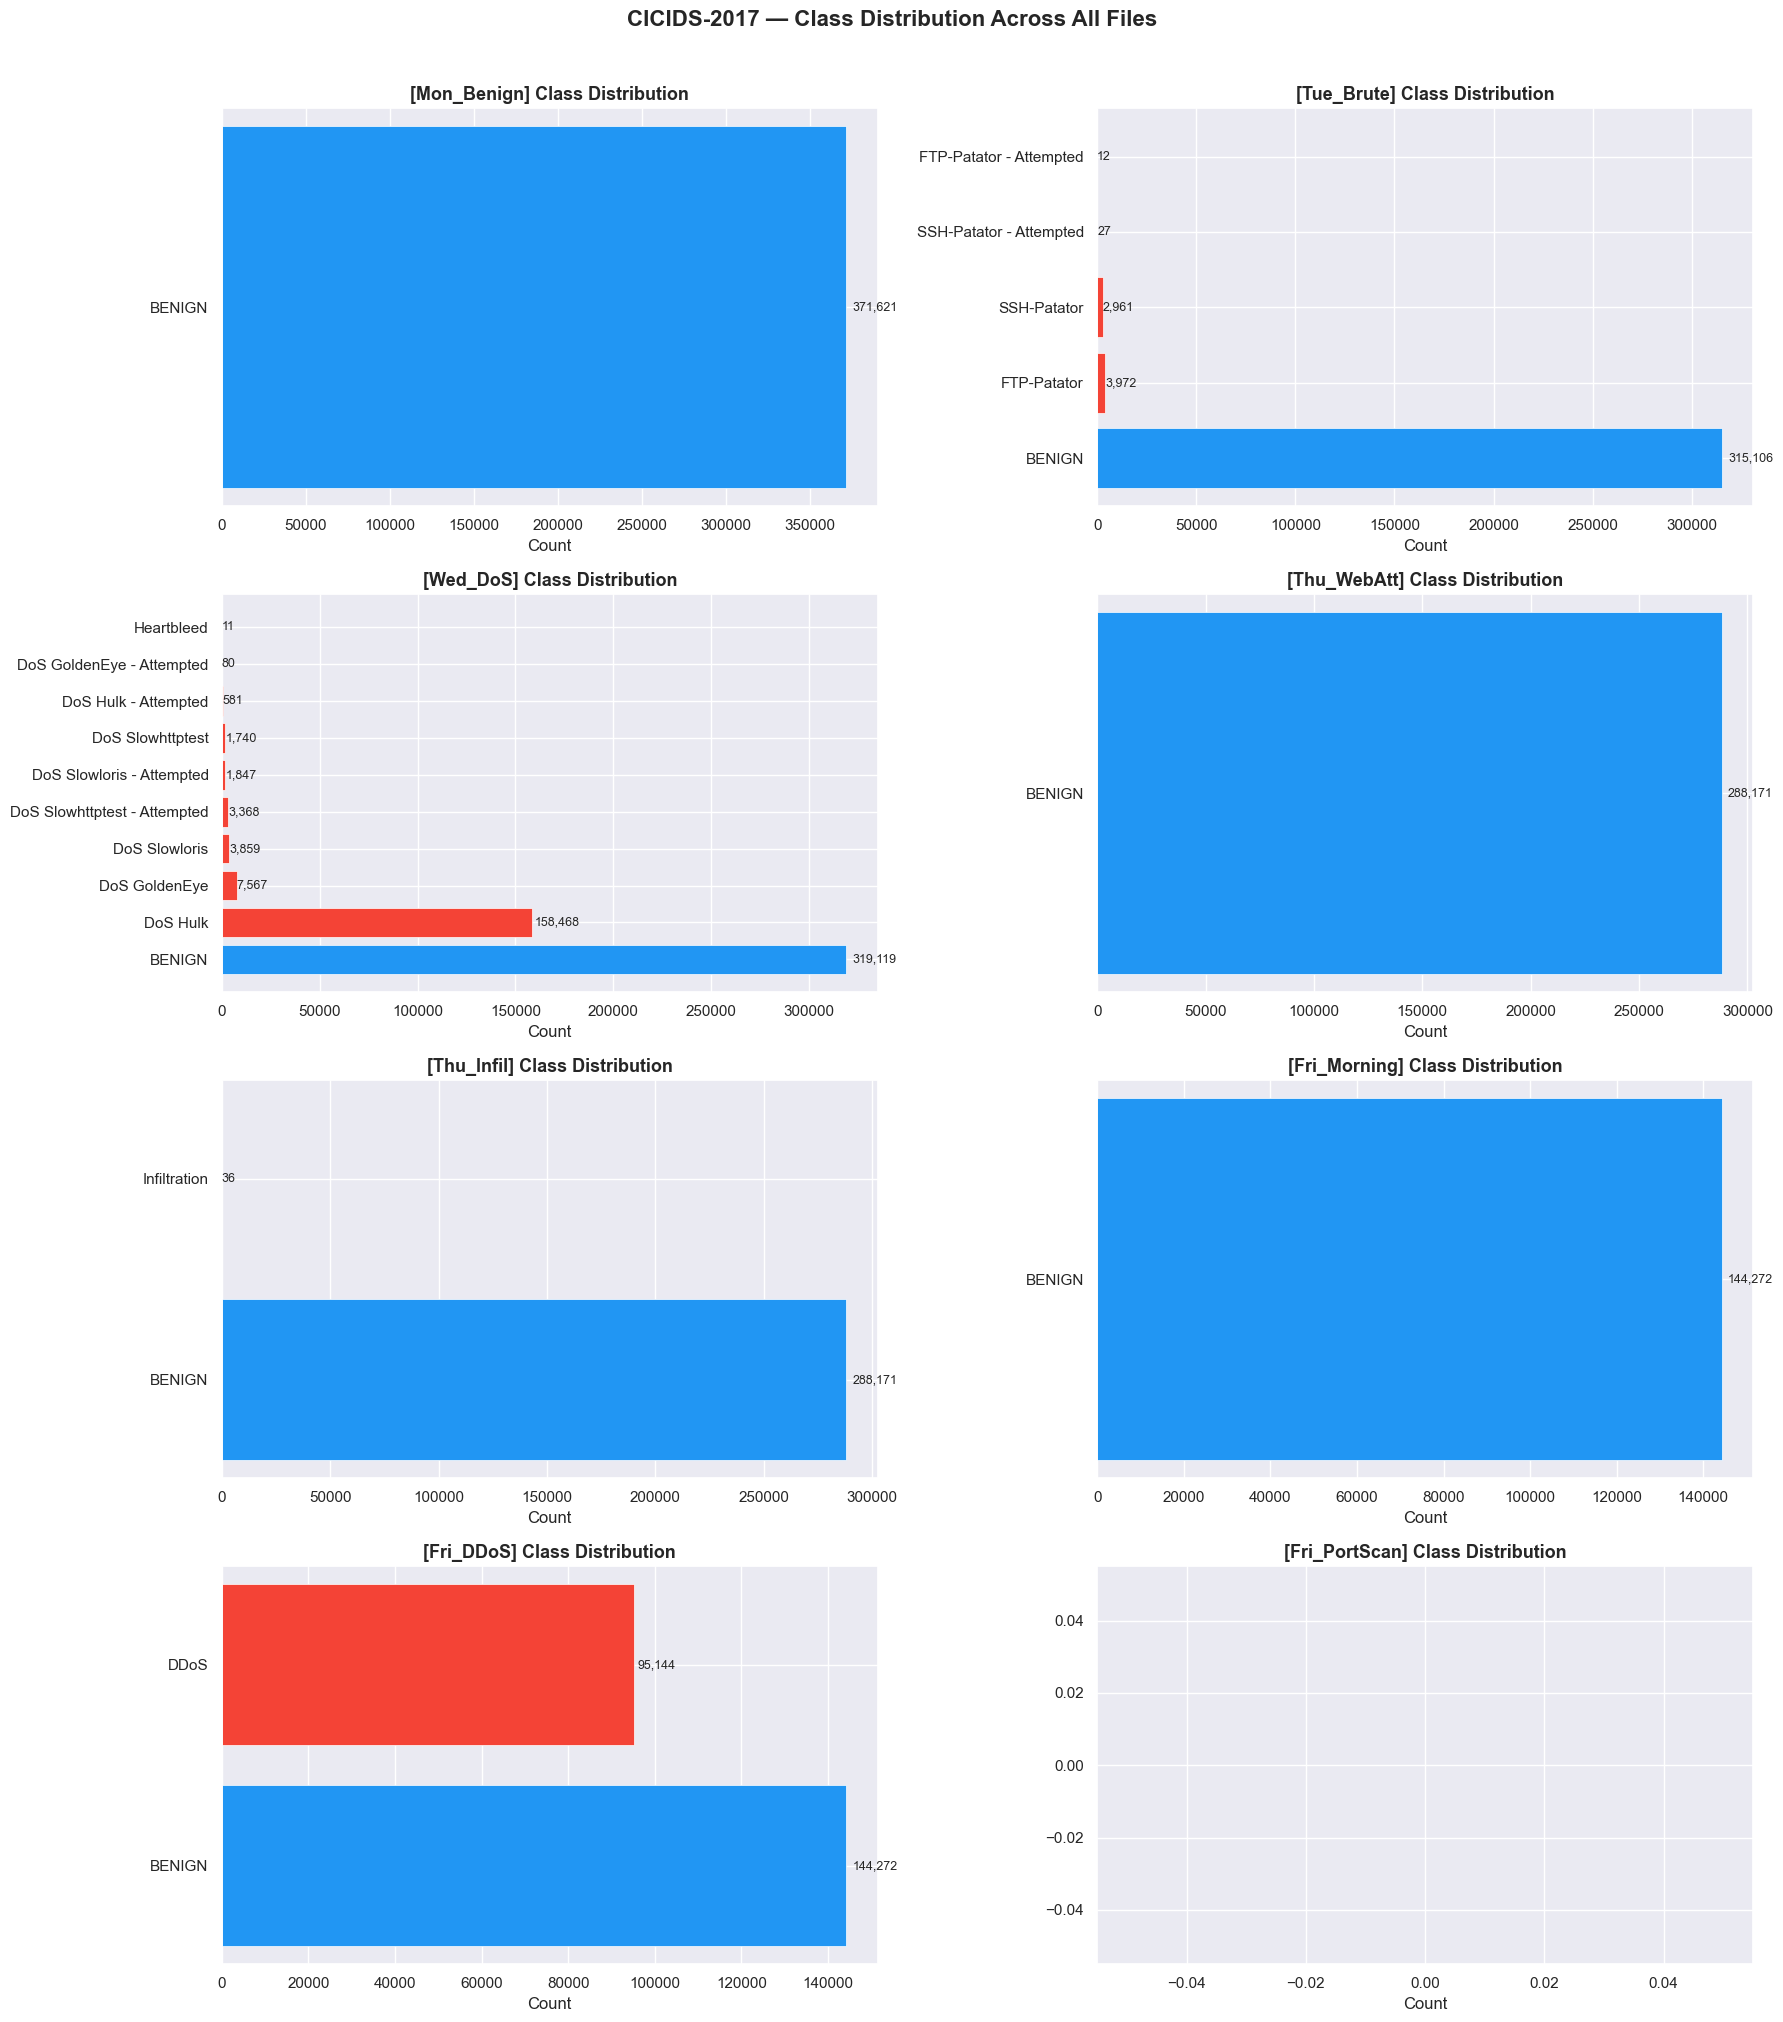

📁 Saved: 01_class_distribution_all.png


In [36]:
n_files = len(datasets)
ncols = 2
nrows = (n_files + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

for idx, (tag, df) in enumerate(datasets.items()):
    ax = axes[idx]
    counts = df[TARGET_COL].value_counts()
    colors = ['#2196F3' if l == 'BENIGN' else '#F44336' for l in counts.index]

    bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f"[{tag}] Class Distribution", fontsize=13, fontweight='bold')
    ax.set_xlabel('Count')

    # Add count labels on bars
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

# Hide unused subplots
for i in range(len(datasets), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('CICIDS-2017 — Class Distribution Across All Files', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_class_distribution_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: 01_class_distribution_all.png")

## Cell 7 — Global Label Distribution (Combined View)

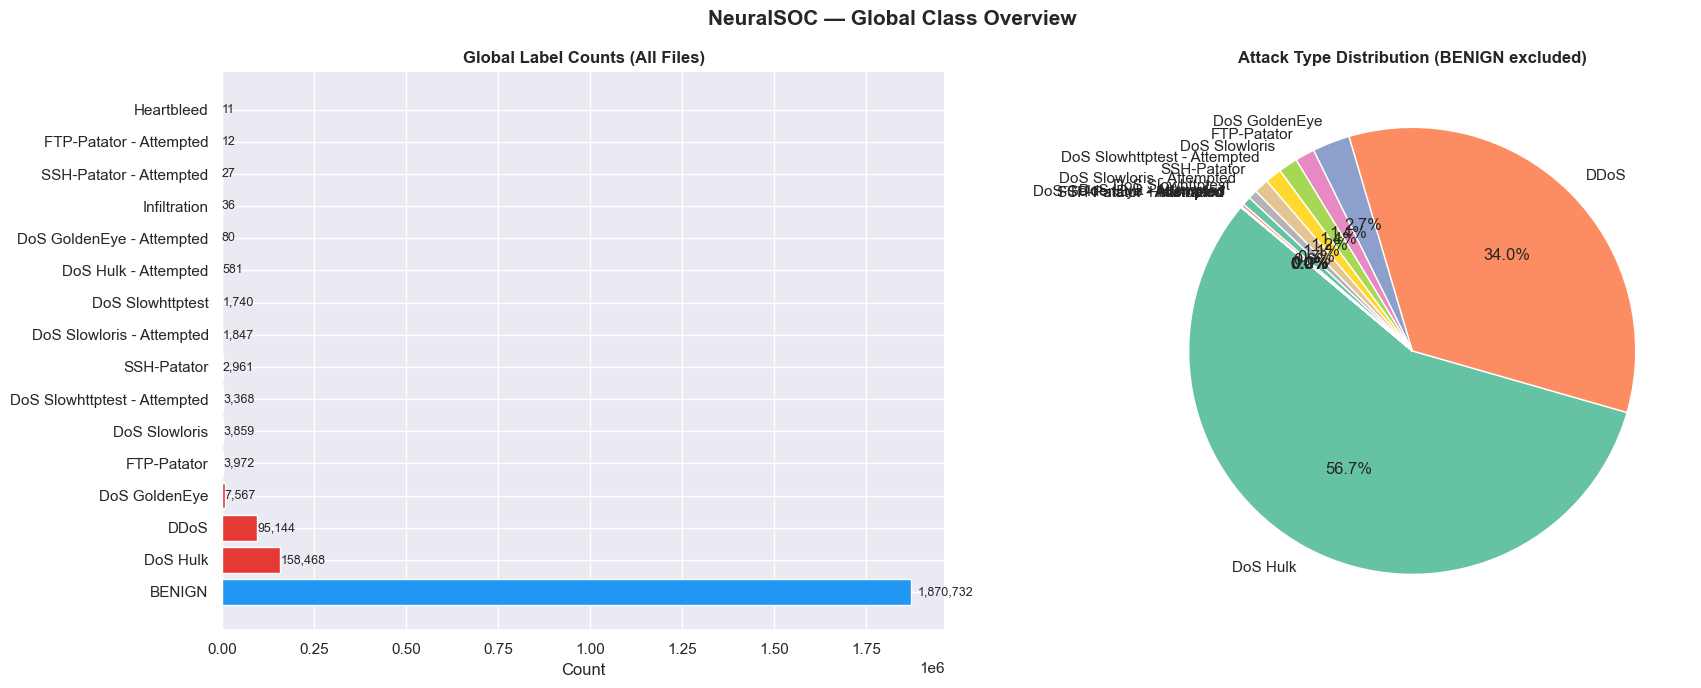


Total samples across all files: 2,150,405
Unique attack labels: 15

Label
BENIGN                          1870732
DoS Hulk                         158468
DDoS                              95144
DoS GoldenEye                      7567
FTP-Patator                        3972
DoS Slowloris                      3859
DoS Slowhttptest - Attempted       3368
SSH-Patator                        2961
DoS Slowloris - Attempted          1847
DoS Slowhttptest                   1740
DoS Hulk - Attempted                581
DoS GoldenEye - Attempted            80
Infiltration                         36
SSH-Patator - Attempted              27
FTP-Patator - Attempted              12
Heartbleed                           11


In [37]:
# Aggregate label counts across all files
all_labels = pd.concat([df[TARGET_COL] for df in datasets.values()], ignore_index=True)
global_counts = all_labels.value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart
bar_colors = ['#2196F3' if l == 'BENIGN' else '#E53935' for l in global_counts.index]
ax1.barh(global_counts.index, global_counts.values, color=bar_colors, edgecolor='white')
ax1.set_title('Global Label Counts (All Files)', fontweight='bold')
ax1.set_xlabel('Count')
for i, (label, val) in enumerate(global_counts.items()):
    ax1.text(val * 1.01, i, f'{val:,}', va='center', fontsize=9)

# Pie chart (exclude BENIGN for clarity on attacks)
attack_counts = global_counts[global_counts.index != 'BENIGN']
ax2.pie(attack_counts.values, labels=attack_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Set2', len(attack_counts)))
ax2.set_title('Attack Type Distribution (BENIGN excluded)', fontweight='bold')

plt.suptitle('NeuralSOC — Global Class Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_global_label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal samples across all files: {len(all_labels):,}")
print(f"Unique attack labels: {len(global_counts) - 1}")
print(f"\n{global_counts.to_string()}")

## Cell 8 — Missing Values & Infinity Check (Per File)

In [38]:
print("Checking for residual nulls and infinities after cleaning...\n")
quality_report = []

for tag, df in datasets.items():
    num_df = df.select_dtypes(include=[np.number])
    null_total   = df.isnull().sum().sum()
    inf_total    = np.isinf(num_df.values).sum()
    dup_total    = df.duplicated().sum()

    quality_report.append({
        'File': tag, 'Rows': len(df),
        'Null Cells': null_total, 'Inf Cells': inf_total, 'Duplicates': dup_total,
        'Numeric Cols': num_df.shape[1]
    })
    status = '✅ Clean' if (null_total + inf_total) == 0 else '⚠️  Issues'
    print(f"  [{tag:15s}]  Nulls={null_total}  Infs={inf_total}  Dups={dup_total}  {status}")

quality_df = pd.DataFrame(quality_report)
quality_df.to_csv(f"{OUTPUT_DIR}/03_data_quality_report.csv", index=False)
print("\n📁 Saved: 03_data_quality_report.csv")

Checking for residual nulls and infinities after cleaning...

  [Mon_Benign     ]  Nulls=0  Infs=0  Dups=4  ✅ Clean
  [Tue_Brute      ]  Nulls=0  Infs=0  Dups=6  ✅ Clean
  [Wed_DoS        ]  Nulls=0  Infs=0  Dups=6  ✅ Clean
  [Thu_WebAtt     ]  Nulls=0  Infs=0  Dups=4  ✅ Clean
  [Thu_Infil      ]  Nulls=0  Infs=0  Dups=4  ✅ Clean
  [Fri_Morning    ]  Nulls=0  Infs=0  Dups=1  ✅ Clean
  [Fri_DDoS       ]  Nulls=0  Infs=0  Dups=0  ✅ Clean
  [Fri_PortScan   ]  Nulls=0  Infs=0  Dups=0  ✅ Clean

📁 Saved: 03_data_quality_report.csv


## Cell 9 — Feature Statistics Per File

In [39]:
for tag, df in datasets.items():
    print(f"\n{'═'*70}")
    print(f"  [{tag}] — Numeric Feature Stats")
    print(f"{'═'*70}")

    EXCLUDE = {'Label', 'Attempted Category', 'Timestamp', 'Src IP dec', 'Dst IP dec'}
    for col in df.columns:
        if col not in EXCLUDE:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    num_df = df.select_dtypes(include='number')
    print(f"Numeric cols after fix: {len(num_df.columns)}")  # should be ~85

    print("All columns:", df.columns.tolist())
    print("Numeric cols:", num_df.columns.tolist())
    print("dtypes:\n", df.dtypes.value_counts())

    stats = num_df.describe().T
    stats['cv']      = (stats['std'] / (stats['mean'].abs() + 1e-9)).round(4)
    stats['range']   = stats['max'] - stats['min']
    stats['skew']    = num_df.skew().round(4)

    # Top 10 most variable features
    top10 = stats.sort_values('cv', ascending=False).head(10)
    print(top10[['mean', 'std', 'min', 'max', 'cv', 'skew']].to_string())


══════════════════════════════════════════════════════════════════════
  [Mon_Benign] — Numeric Feature Stats
══════════════════════════════════════════════════════════════════════
Numeric cols after fix: 87
All columns: ['Src IP dec', 'Src Port', 'Dst IP dec', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd RST Flags', 'Bwd RST Flags', 'Fwd Header Length', 'B

## Cell 10 — Near-Zero Variance Feature Detection

In [40]:
nzv_report = {}

for tag, df in datasets.items():
    num_df = df.select_dtypes(include=[np.number])
    low_var_cols = num_df.var()[num_df.var() < 1e-5].index.tolist()
    nzv_report[tag] = low_var_cols
    print(f"  [{tag:15s}]  NZV features ({len(low_var_cols)}): {low_var_cols}")

# Features that are NZV in ALL files → safe to drop globally
if nzv_report:
    all_nzv_sets = [set(v) for v in nzv_report.values()]
    global_nzv = set.intersection(*all_nzv_sets)
    print(f"\n🚫 Features NZV in ALL files (safe to drop globally): {list(global_nzv)}")

  [Mon_Benign     ]  NZV features (4): ['Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'Attempted Category']
  [Tue_Brute      ]  NZV features (3): ['Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count']
  [Wed_DoS        ]  NZV features (3): ['Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count']
  [Thu_WebAtt     ]  NZV features (2): ['Fwd URG Flags', 'Attempted Category']
  [Thu_Infil      ]  NZV features (2): ['Fwd URG Flags', 'Attempted Category']
  [Fri_Morning    ]  NZV features (5): ['Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'Subflow Bwd Packets', 'Attempted Category']
  [Fri_DDoS       ]  NZV features (5): ['Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'Subflow Bwd Packets', 'Attempted Category']
  [Fri_PortScan   ]  NZV features (0): []

🚫 Features NZV in ALL files (safe to drop globally): []


## Cell 11 — Correlation Heatmaps (Per File, Top 20 Features)

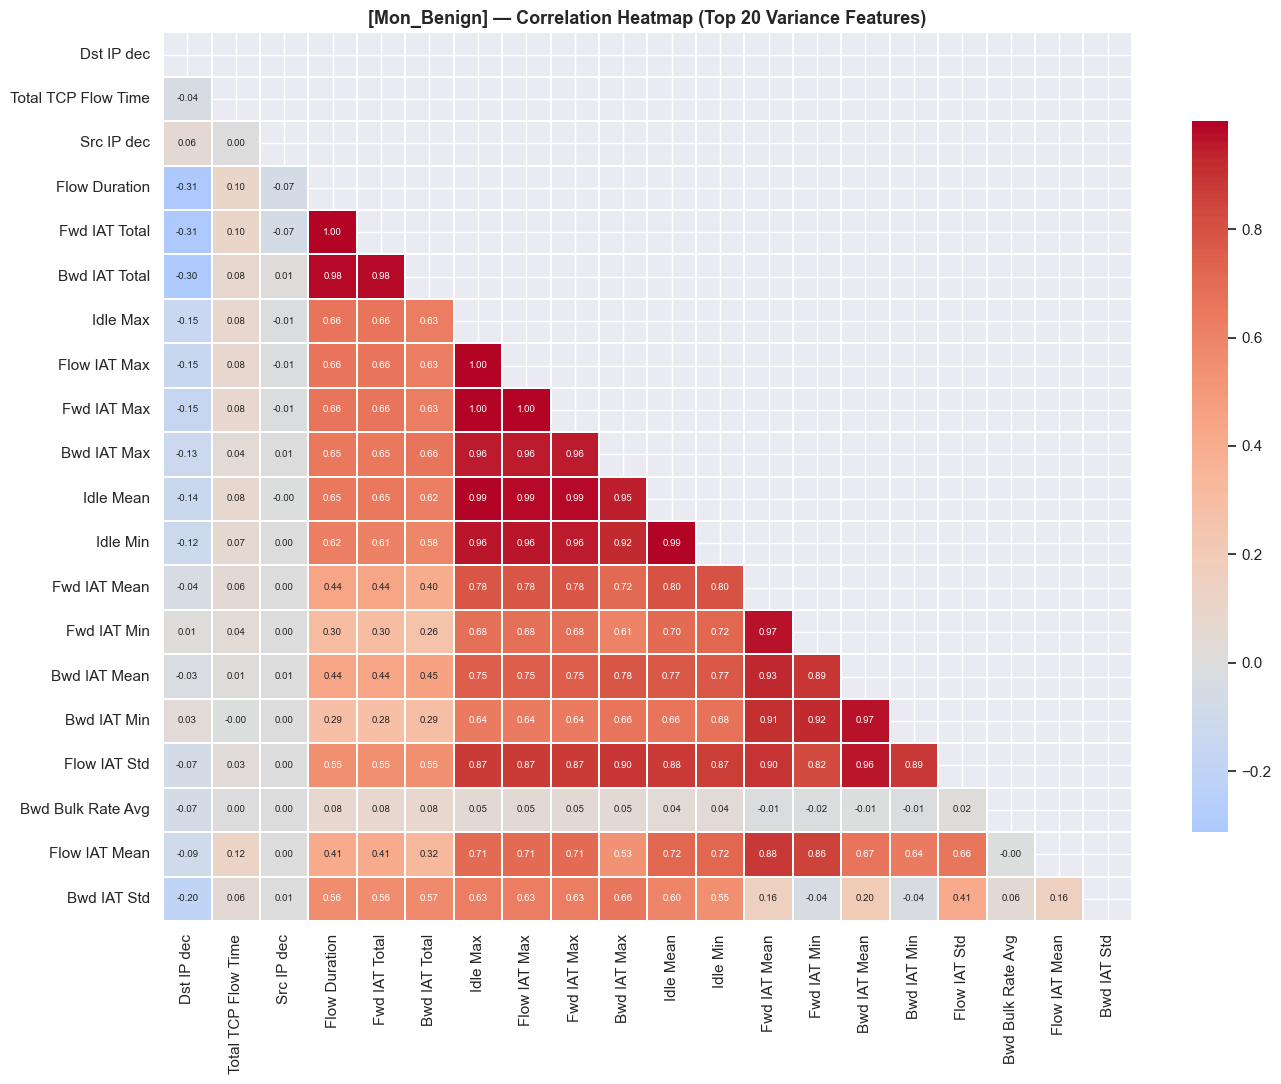

📁 Saved: 04_corr_Mon_Benign.png


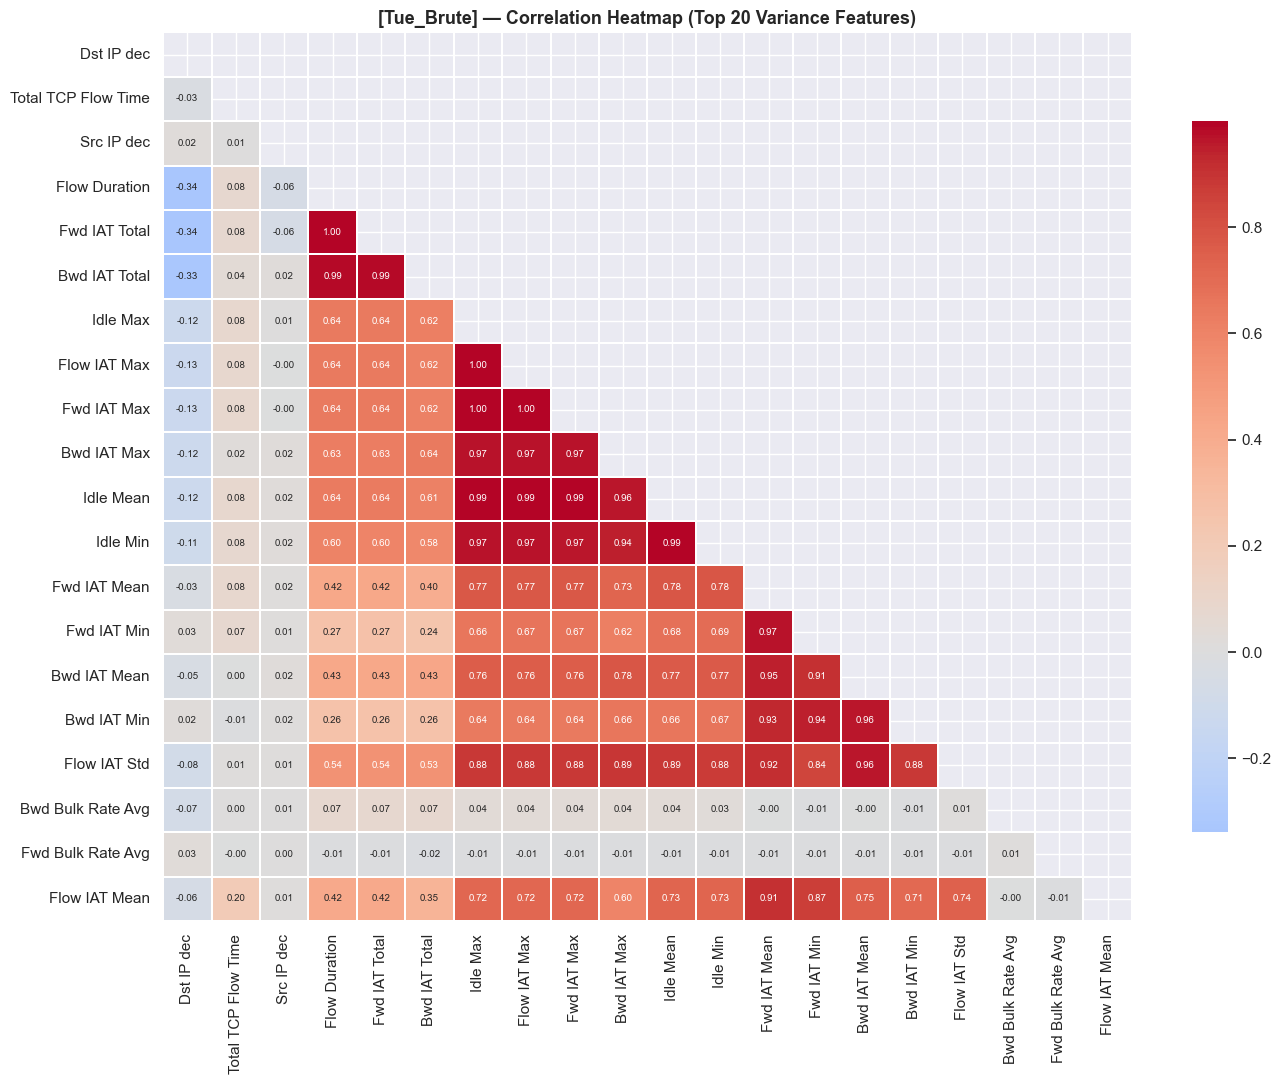

📁 Saved: 04_corr_Tue_Brute.png


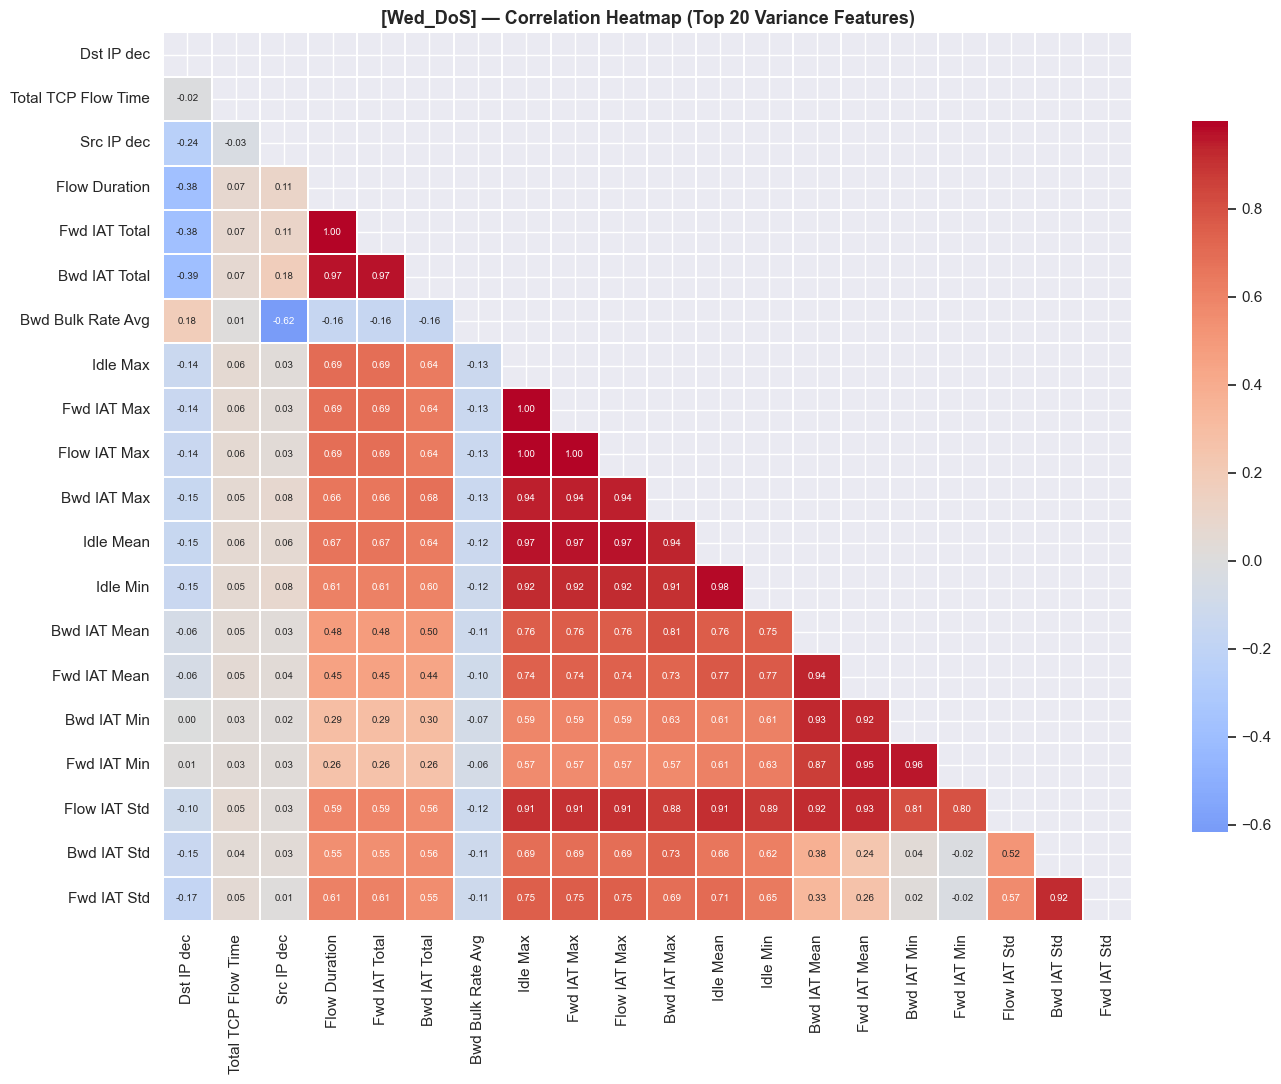

📁 Saved: 04_corr_Wed_DoS.png


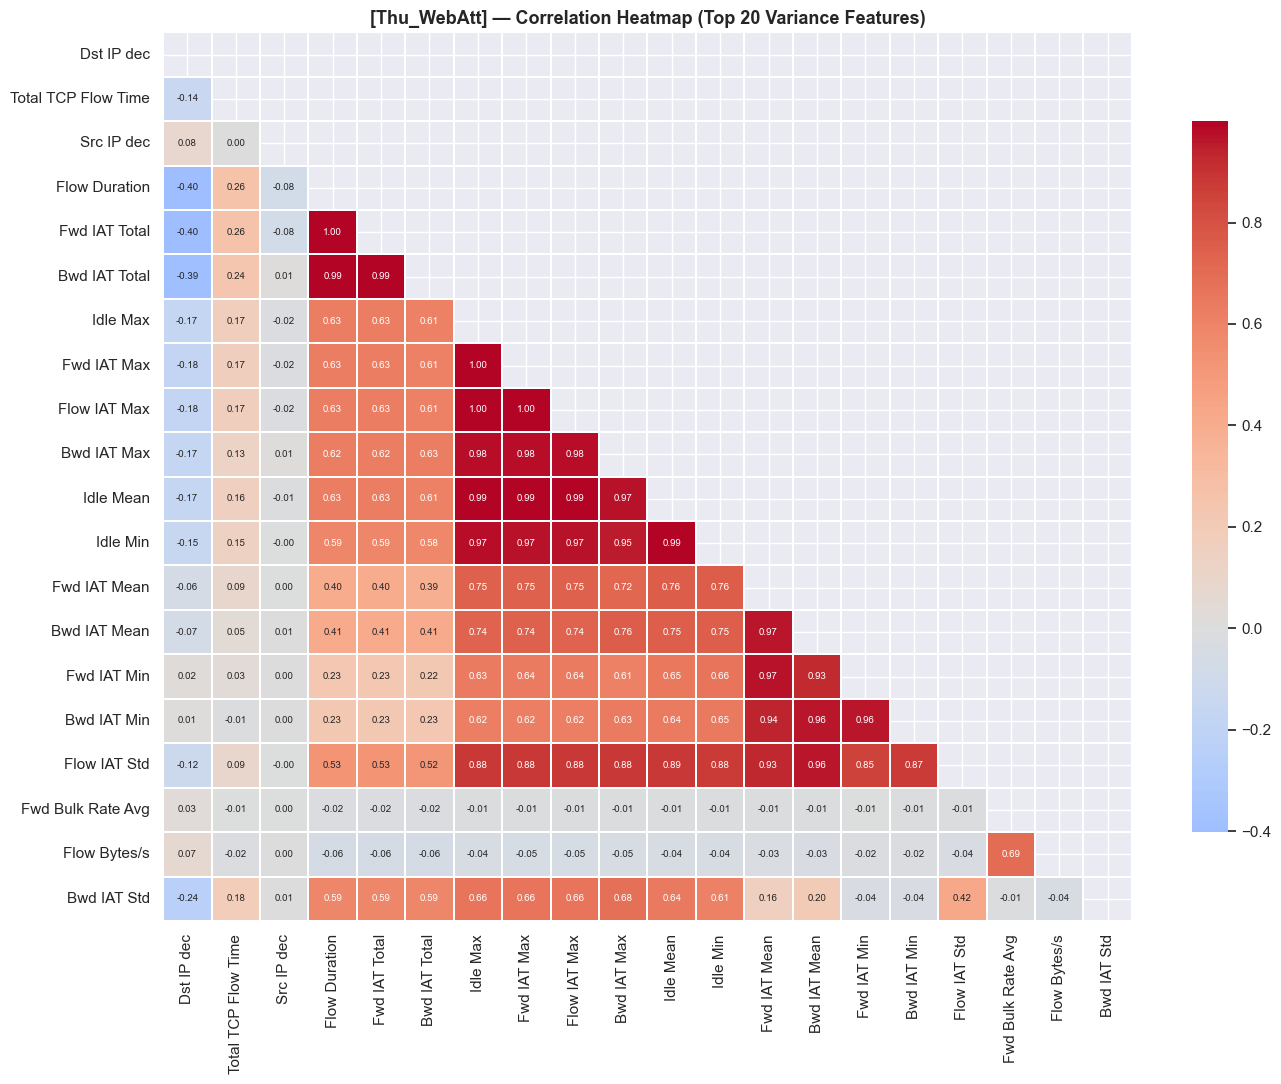

📁 Saved: 04_corr_Thu_WebAtt.png


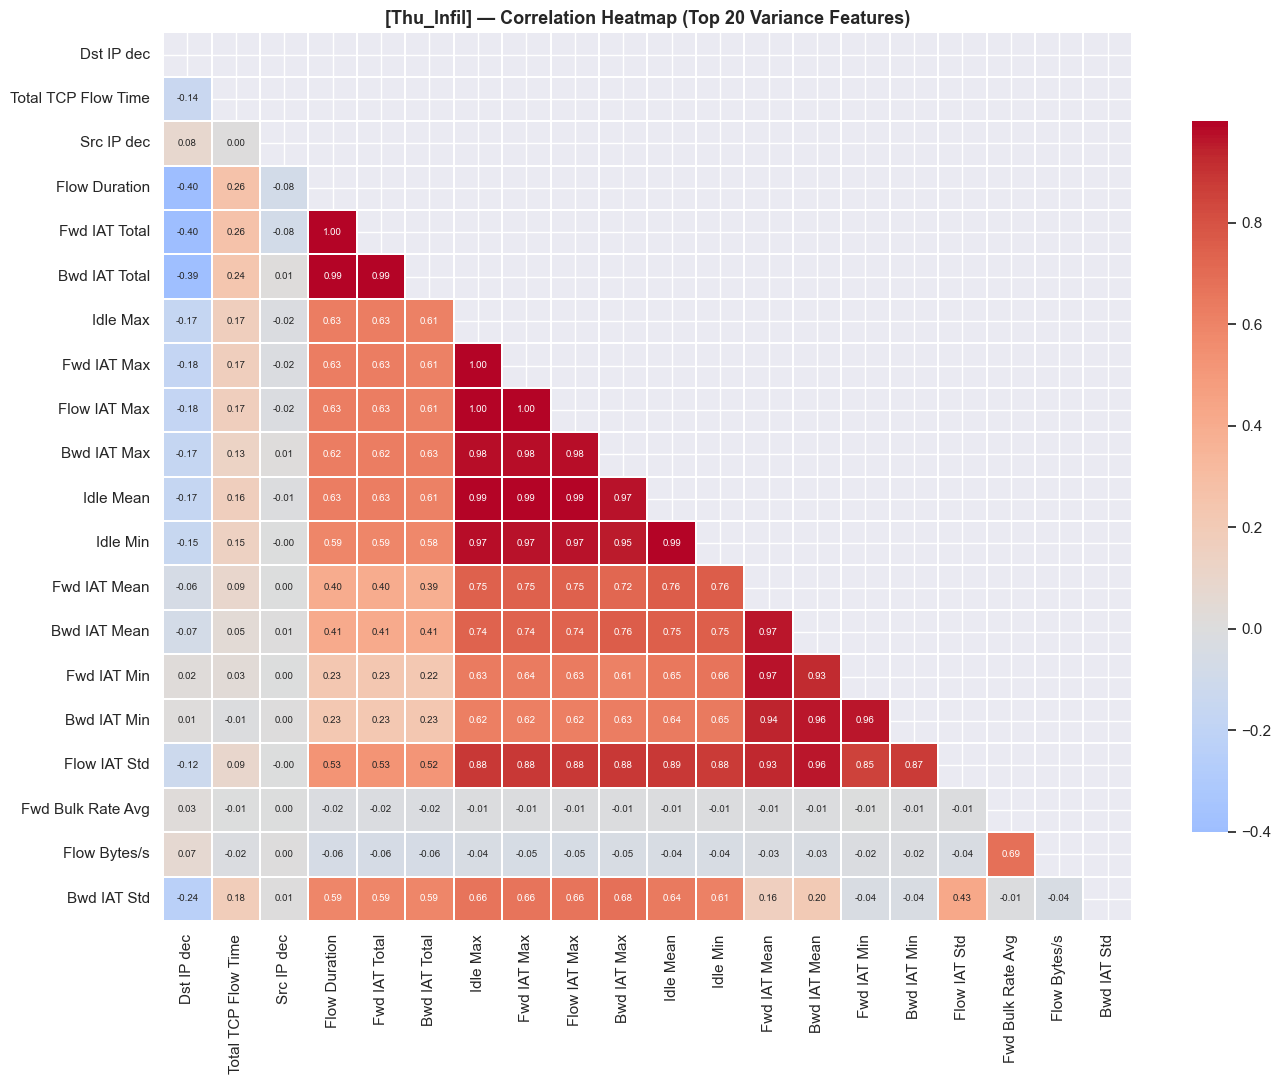

📁 Saved: 04_corr_Thu_Infil.png


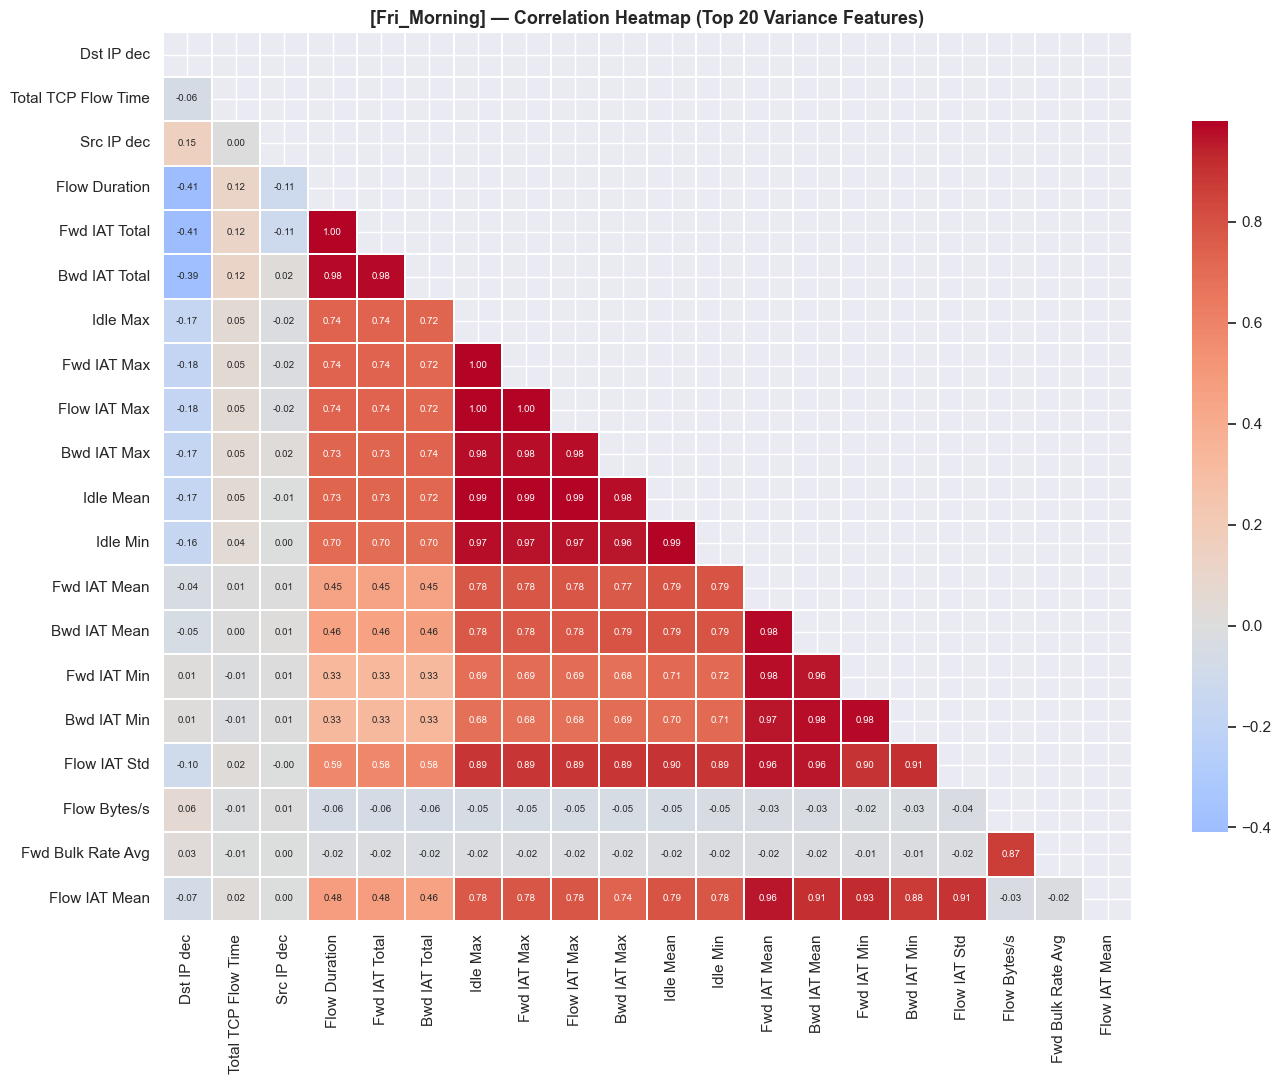

📁 Saved: 04_corr_Fri_Morning.png


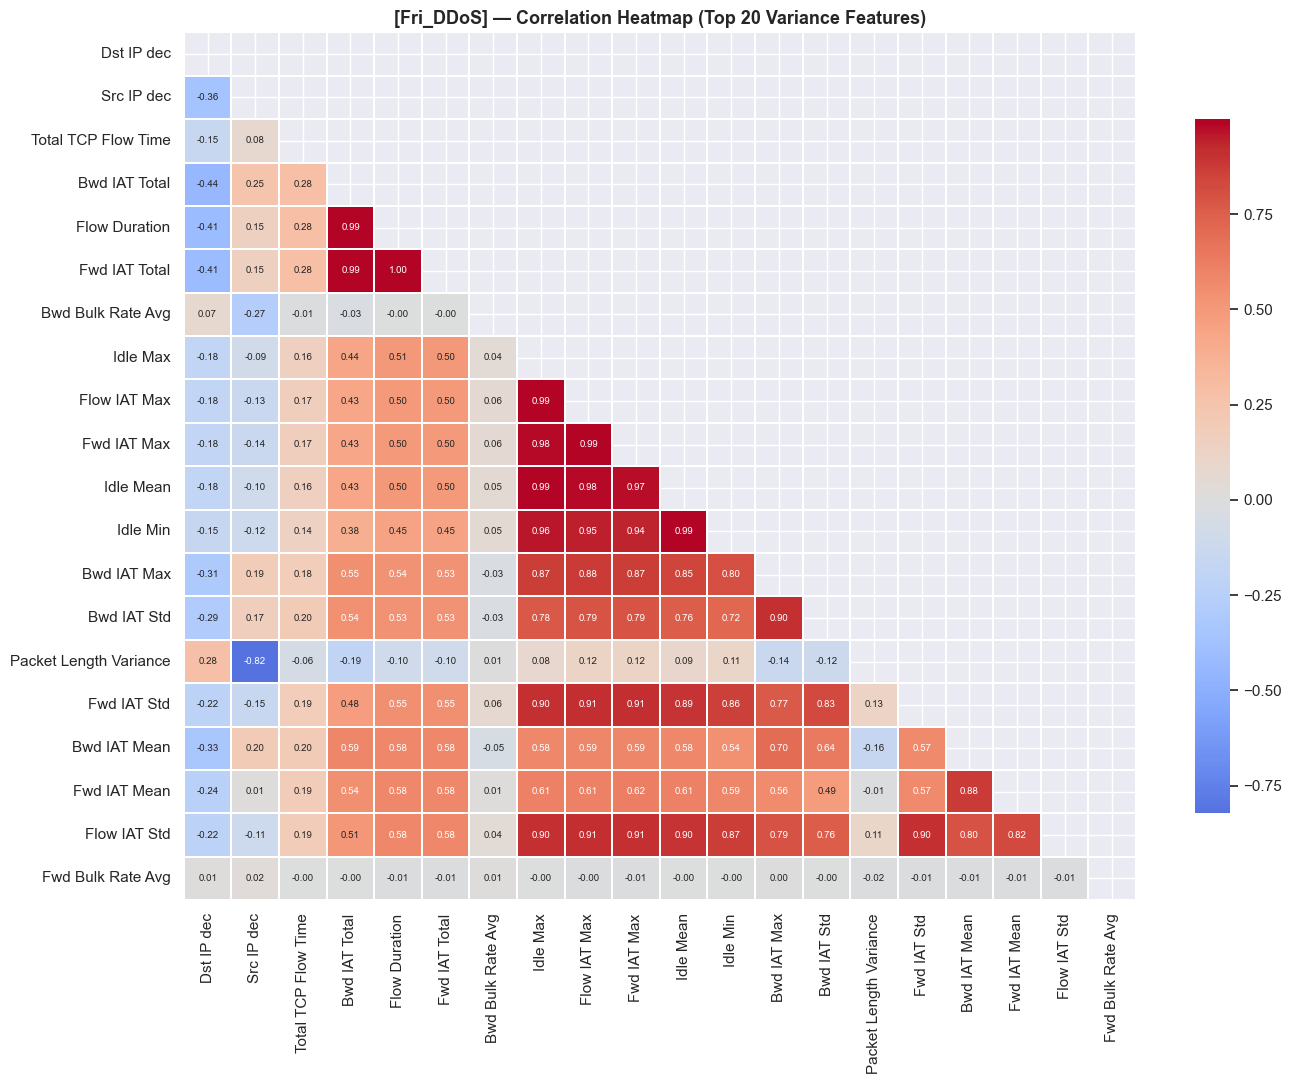

📁 Saved: 04_corr_Fri_DDoS.png


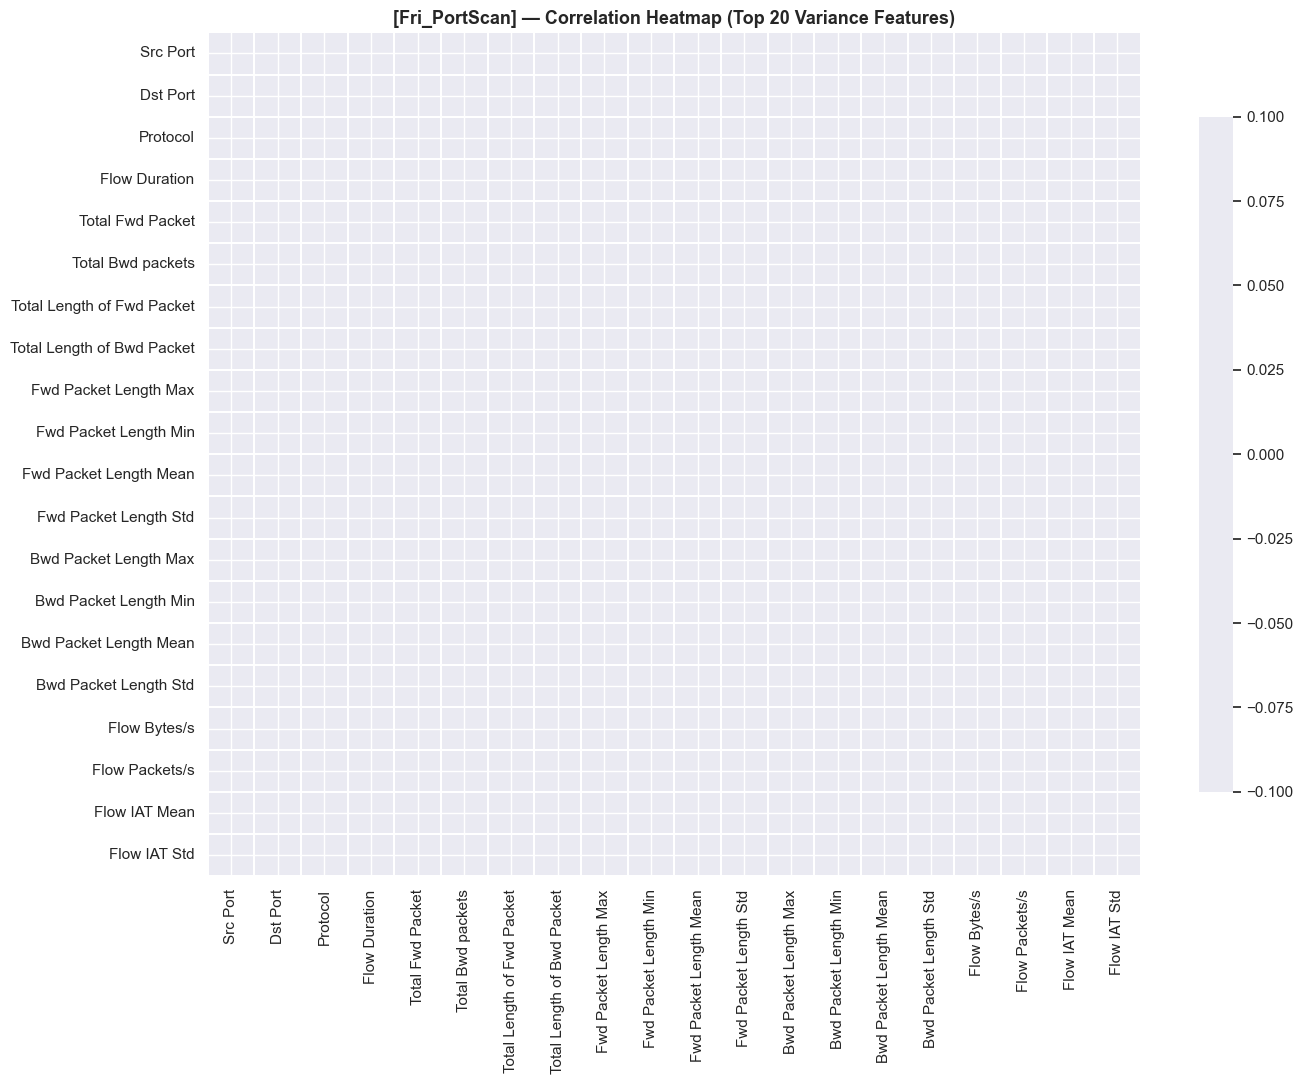

📁 Saved: 04_corr_Fri_PortScan.png


In [41]:
for tag, df in datasets.items():
    num_df = df.select_dtypes(include=[np.number])
    top20  = num_df.var().sort_values(ascending=False).head(20).index

    fig, ax = plt.subplots(figsize=(14, 11))
    corr = num_df[top20].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))   # Upper triangle mask

    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
                linewidths=0.3, annot=True, fmt='.2f',
                annot_kws={'size': 7}, ax=ax,
                cbar_kws={'shrink': 0.8})

    ax.set_title(f'[{tag}] — Correlation Heatmap (Top 20 Variance Features)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/04_corr_{tag}.png", dpi=130, bbox_inches='tight')
    plt.show()
    print(f"📁 Saved: 04_corr_{tag}.png")

## Cell 12 — Highly Correlated Feature Pairs (Threshold = 0.95)

In [42]:
drop_corr_report = {}

for tag, df in datasets.items():
    num_df = df.select_dtypes(include=[np.number])
    corr   = num_df.corr().abs()
    upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    high_corr_pairs = [
        (col, row, round(upper.loc[row, col], 4))
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95
    ]

    to_drop = list(set([col for col, _, _ in high_corr_pairs]))
    drop_corr_report[tag] = to_drop

    print(f"\n  [{tag}]  High-corr pairs: {len(high_corr_pairs)}  → drop {len(to_drop)} features")
    for f1, f2, v in high_corr_pairs[:5]:
        print(f"      {f1} ↔ {f2}  = {v}")
    if len(high_corr_pairs) > 5:
        print(f"      ... and {len(high_corr_pairs)-5} more")

# Intersection = features consistently redundant across ALL files
if drop_corr_report:
    universal_drop = set.intersection(*[set(v) for v in drop_corr_report.values()])
    print(f"\n🚫 Universally redundant features (drop across all files): {list(universal_drop)}")


  [Mon_Benign]  High-corr pairs: 45  → drop 26 features
      Total Bwd packets ↔ Total Fwd Packet  = 0.9993
      Total Length of Bwd Packet ↔ Total Fwd Packet  = 0.999
      Total Length of Bwd Packet ↔ Total Bwd packets  = 0.9973
      Fwd Packet Length Std ↔ Fwd Packet Length Max  = 0.9521
      Fwd IAT Total ↔ Flow Duration  = 0.9994
      ... and 40 more

  [Tue_Brute]  High-corr pairs: 44  → drop 23 features
      Total Bwd packets ↔ Total Fwd Packet  = 0.9995
      Total Length of Bwd Packet ↔ Total Fwd Packet  = 0.9982
      Total Length of Bwd Packet ↔ Total Bwd packets  = 0.9971
      Fwd IAT Total ↔ Flow Duration  = 0.9995
      Fwd IAT Max ↔ Flow IAT Max  = 0.9984
      ... and 39 more

  [Wed_DoS]  High-corr pairs: 49  → drop 27 features
      Total Bwd packets ↔ Total Fwd Packet  = 0.9989
      Total Length of Bwd Packet ↔ Total Fwd Packet  = 0.9959
      Total Length of Bwd Packet ↔ Total Bwd packets  = 0.9926
      Bwd Packet Length Mean ↔ Bwd Packet Length Max  = 0.9

## Cell 13 — Feature Distribution Plots (Top 6 by Variance per File)

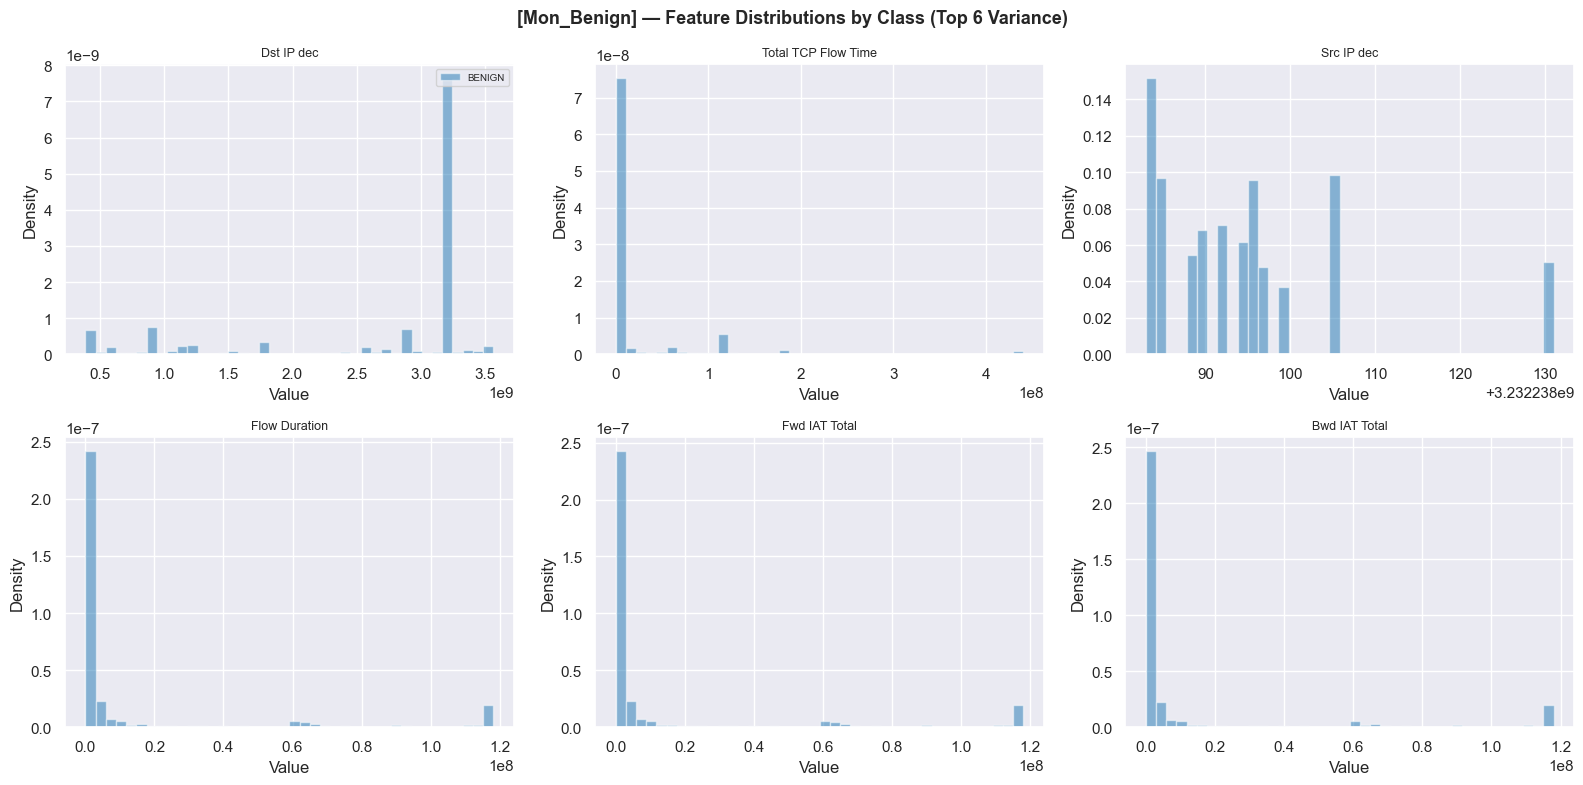

📁 Saved: 05_feat_dist_Mon_Benign.png


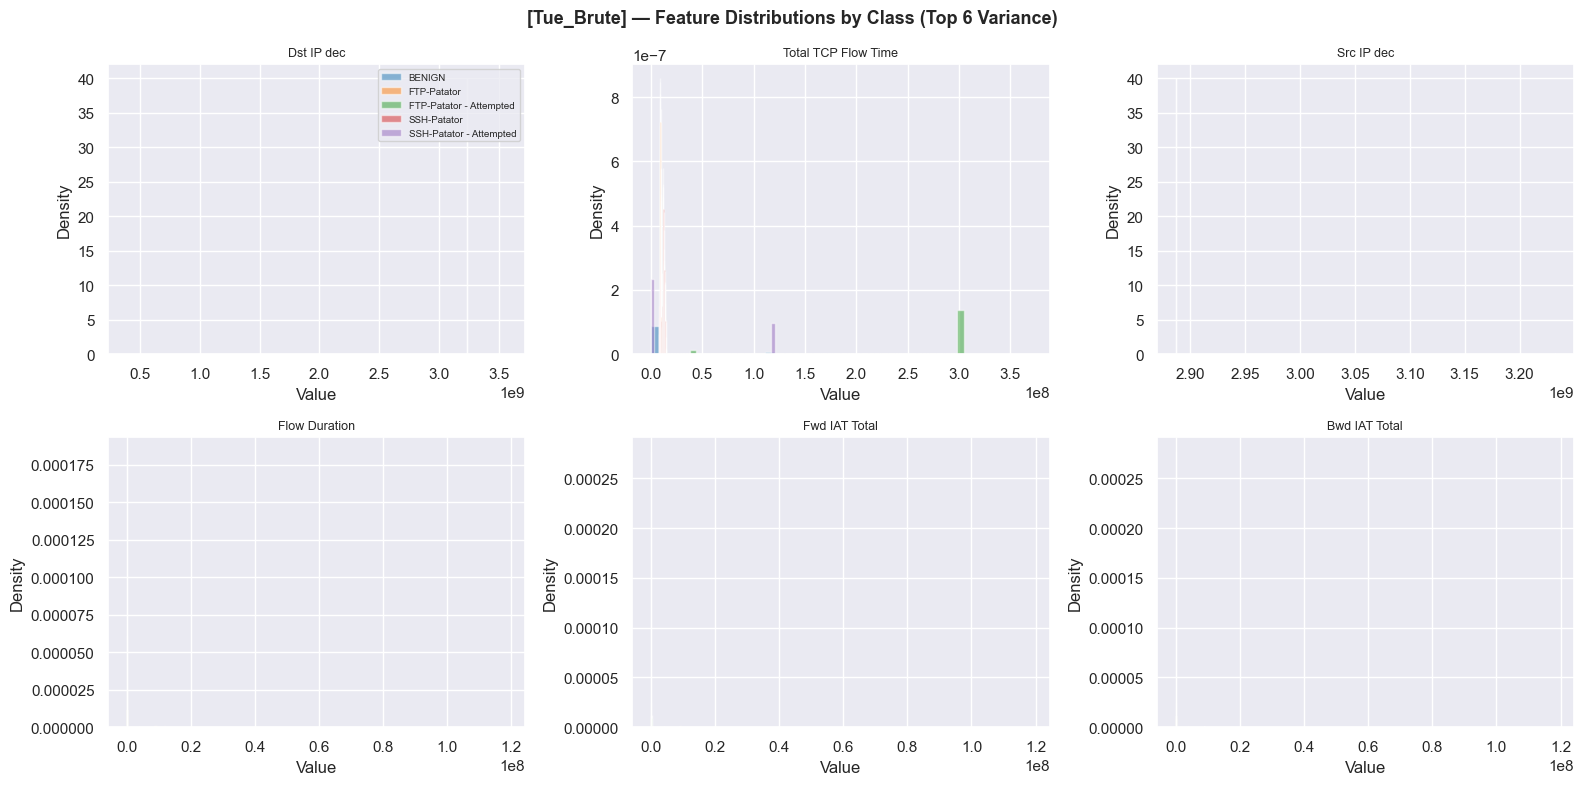

📁 Saved: 05_feat_dist_Tue_Brute.png


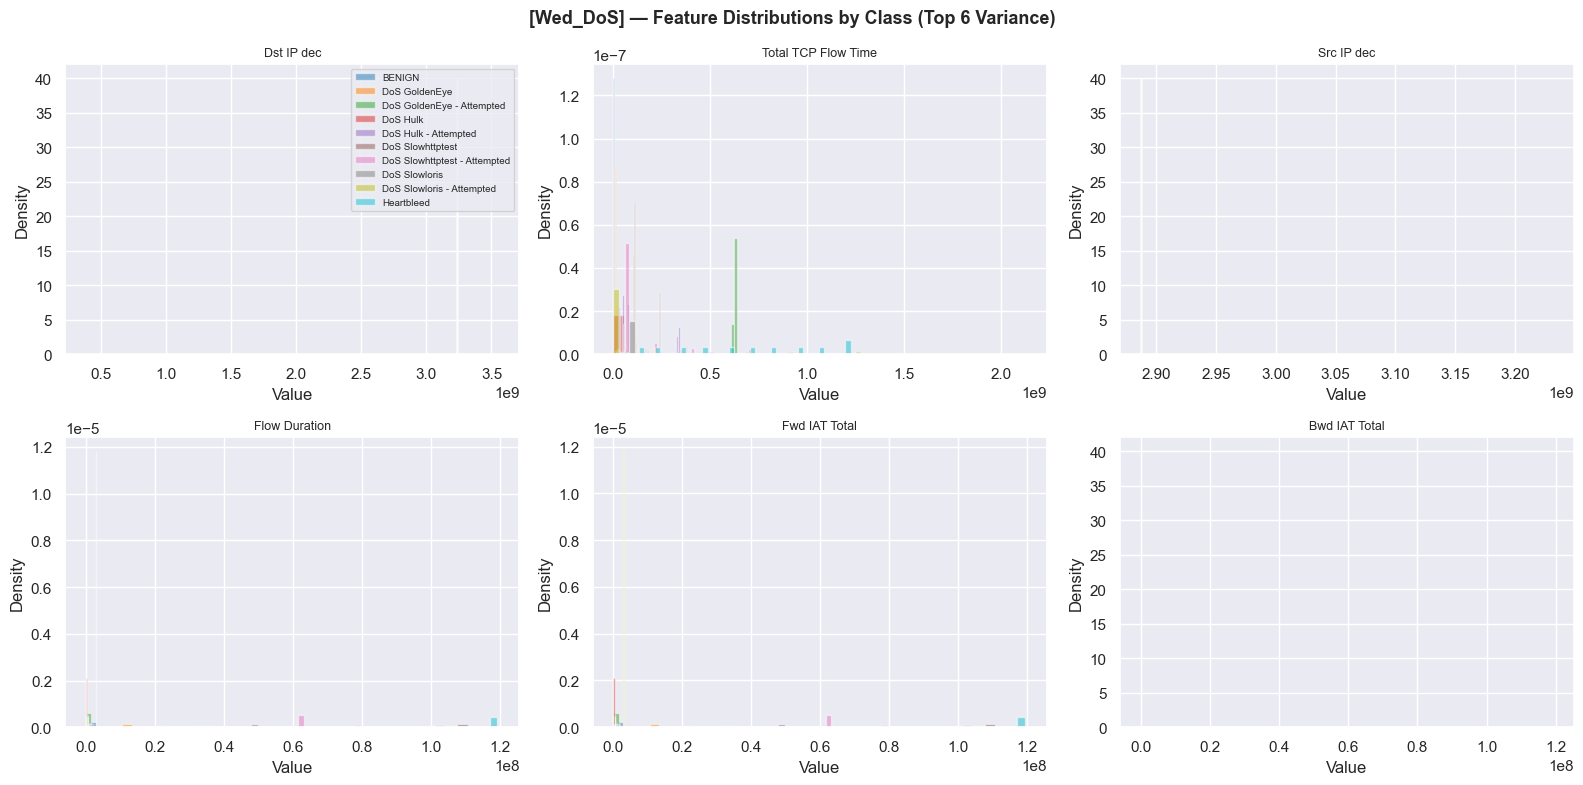

📁 Saved: 05_feat_dist_Wed_DoS.png


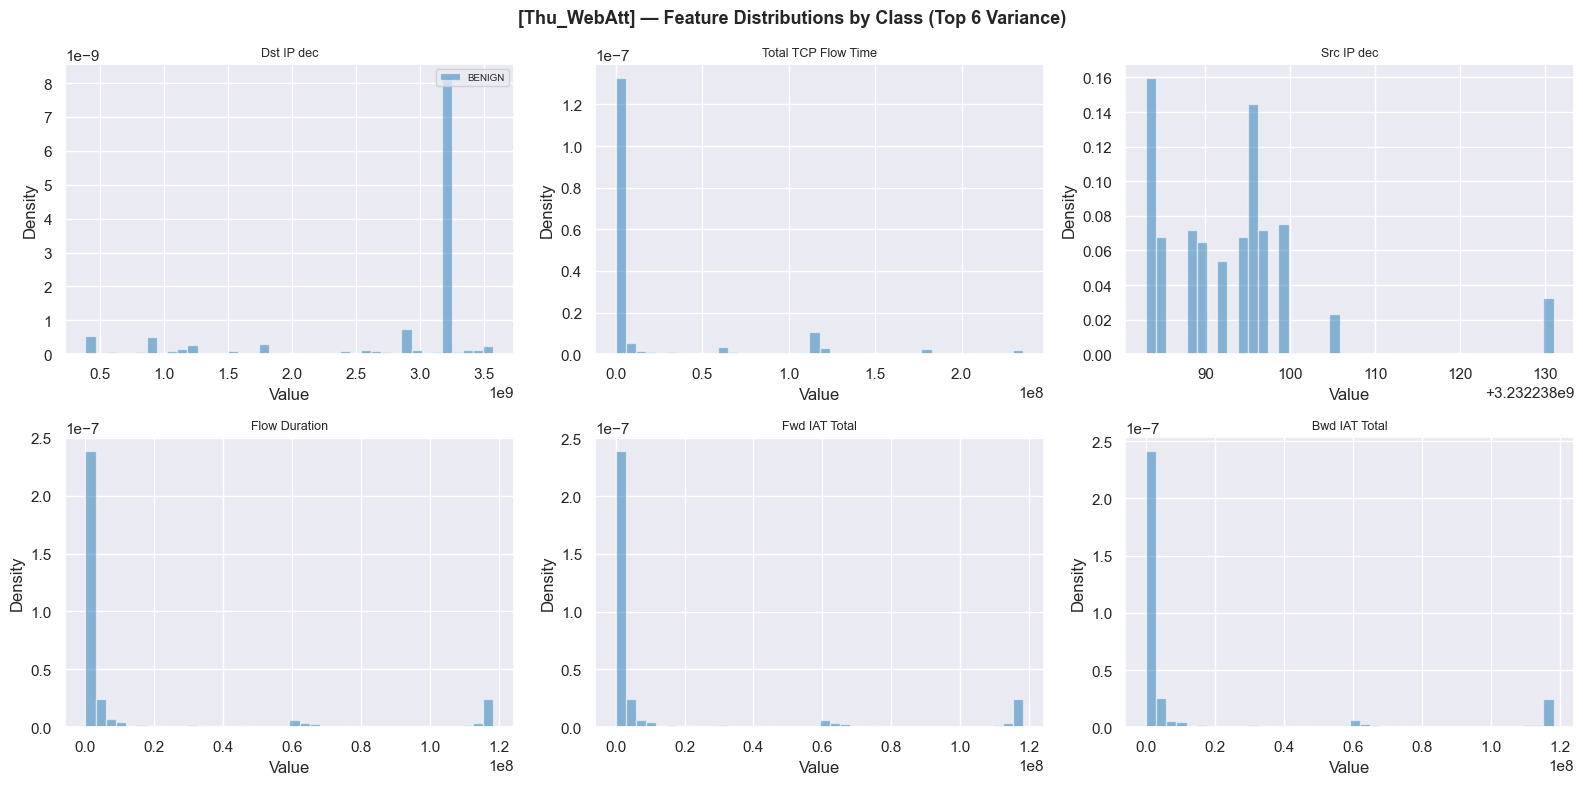

📁 Saved: 05_feat_dist_Thu_WebAtt.png


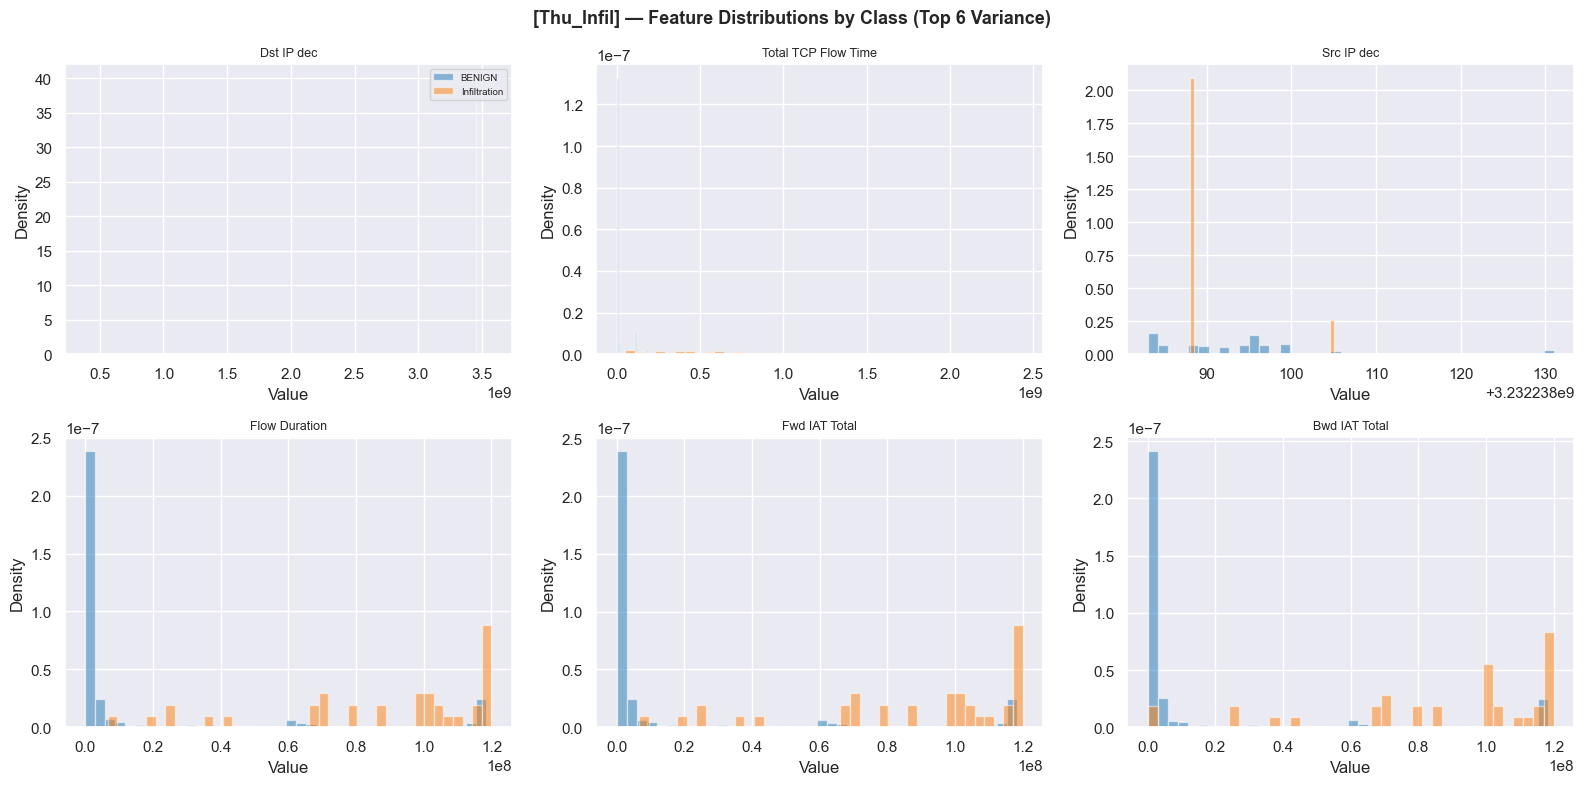

📁 Saved: 05_feat_dist_Thu_Infil.png


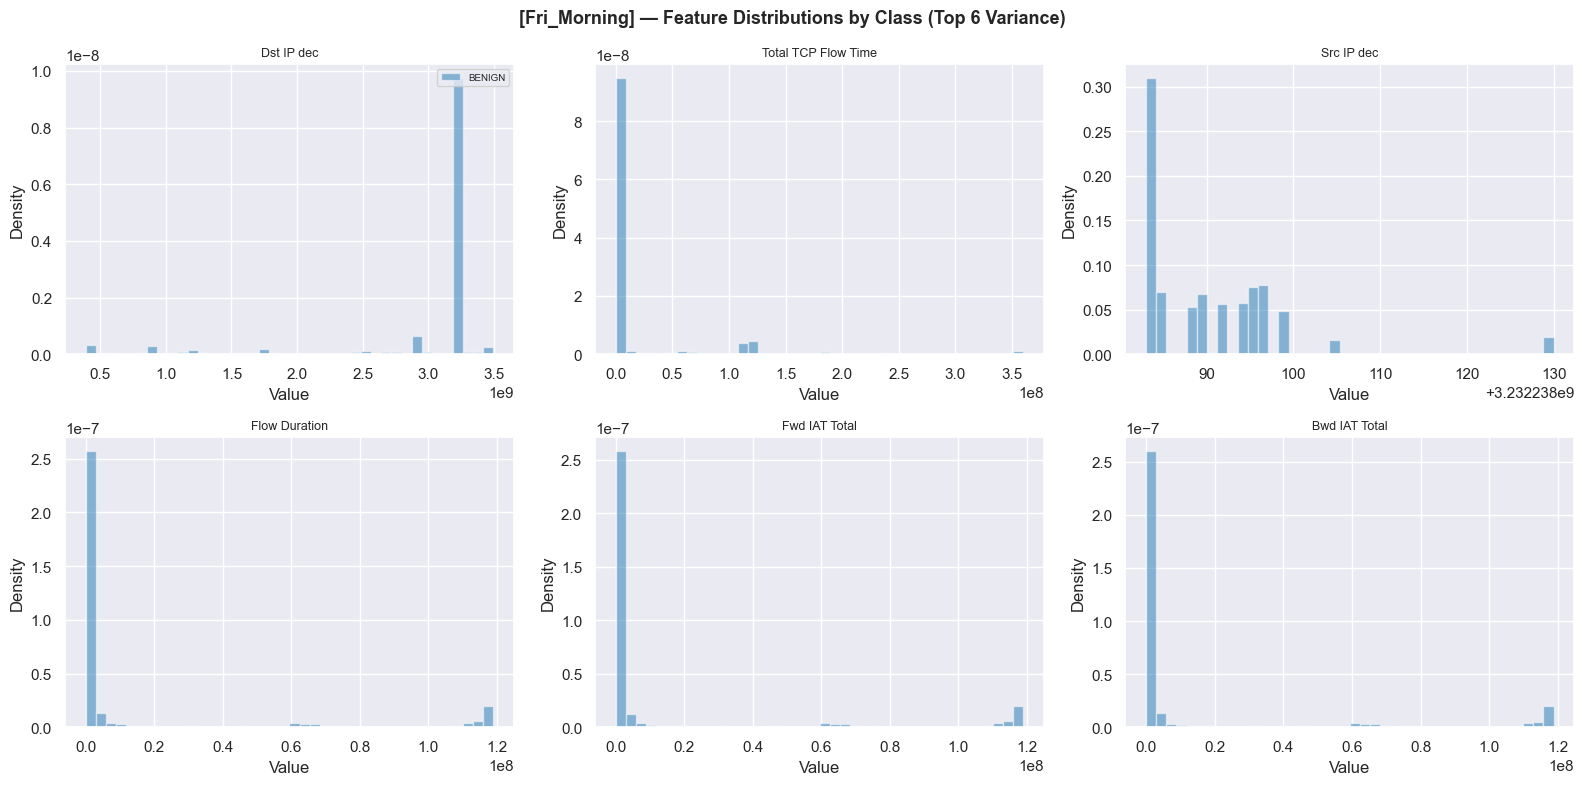

📁 Saved: 05_feat_dist_Fri_Morning.png


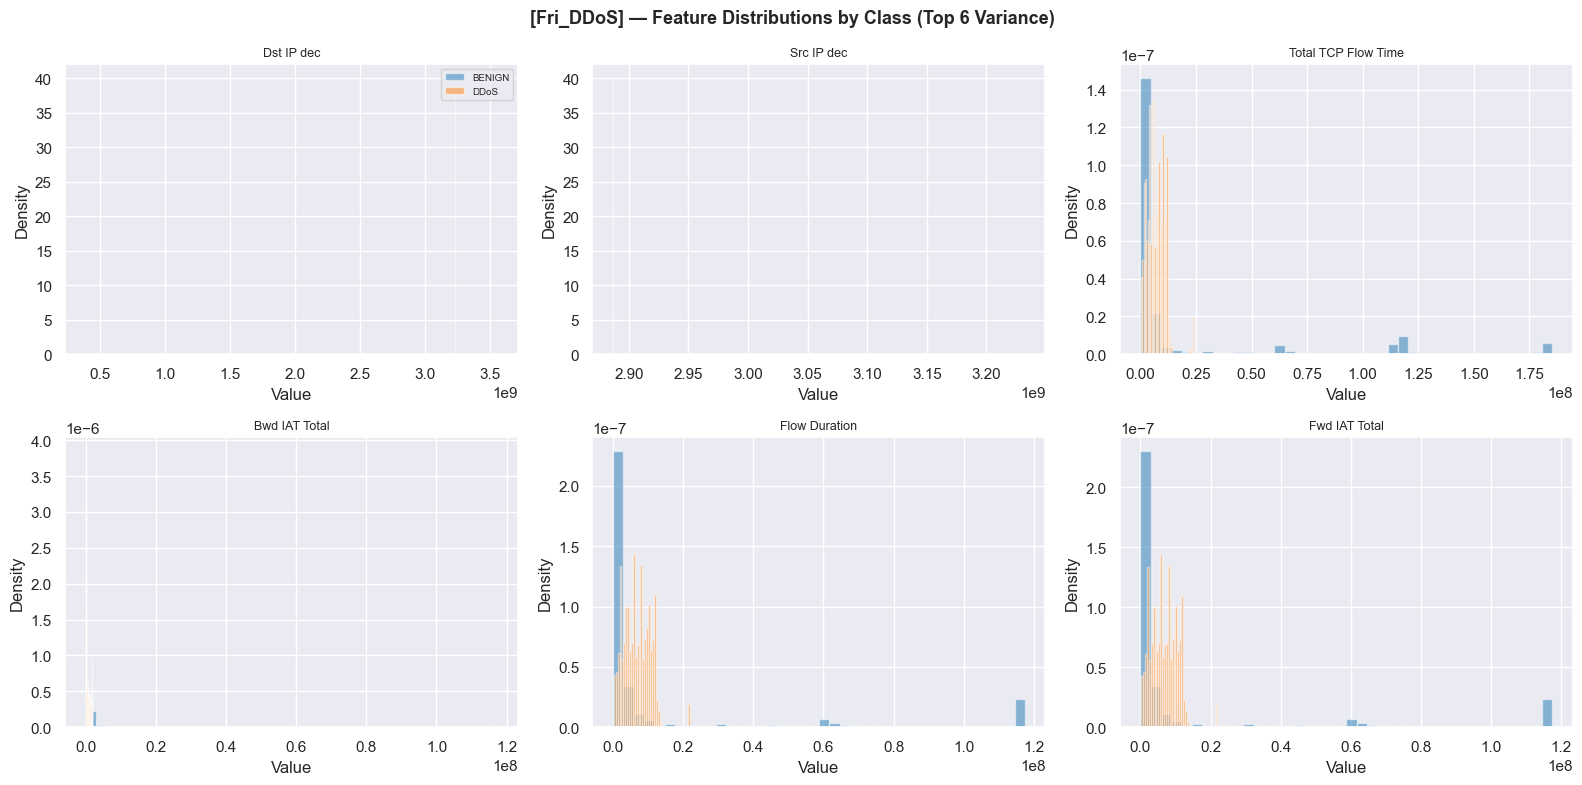

📁 Saved: 05_feat_dist_Fri_DDoS.png


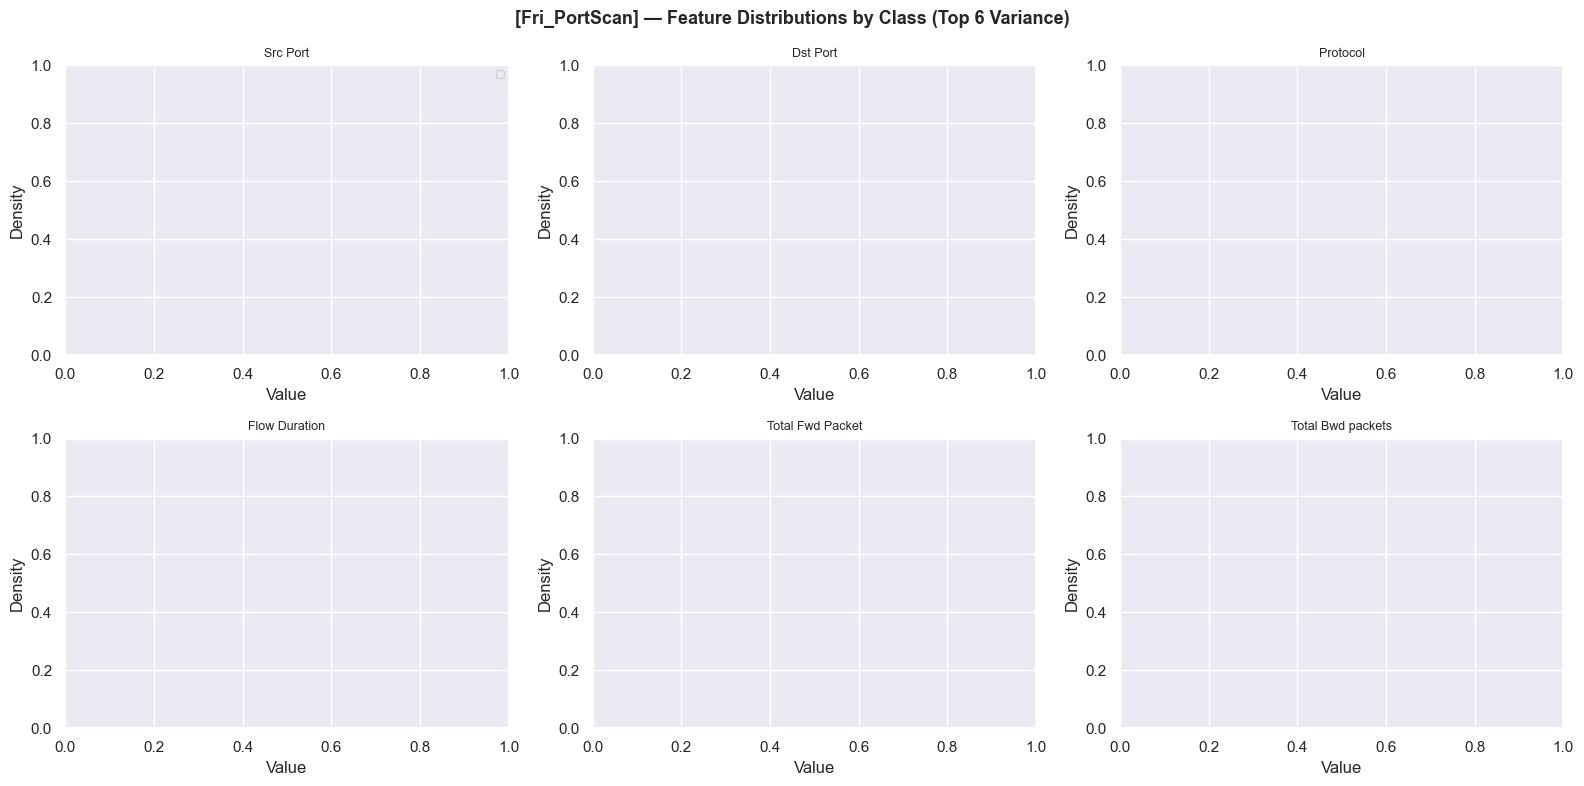

📁 Saved: 05_feat_dist_Fri_PortScan.png


In [43]:
for tag, df in datasets.items():
    num_df  = df.select_dtypes(include=[np.number])
    top6    = num_df.var().sort_values(ascending=False).head(6).index.tolist()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for i, feat in enumerate(top6):
        ax = axes[i]
        for j, (label, grp) in enumerate(df.groupby(TARGET_COL)):
            vals = grp[feat].clip(grp[feat].quantile(0.01), grp[feat].quantile(0.99))
            ax.hist(vals, bins=40, alpha=0.5, label=label,
                    color=COLORS[j % len(COLORS)], density=True)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        if i == 0:
            ax.legend(fontsize=7, loc='upper right')

    plt.suptitle(f'[{tag}] — Feature Distributions by Class (Top 6 Variance)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/05_feat_dist_{tag}.png", dpi=130, bbox_inches='tight')
    plt.show()
    print(f"📁 Saved: 05_feat_dist_{tag}.png")

## Cell 14 — Boxplots: BENIGN vs Attack (Top 5 Features)

[Mon_Benign] — BENIGN only, skipping boxplots


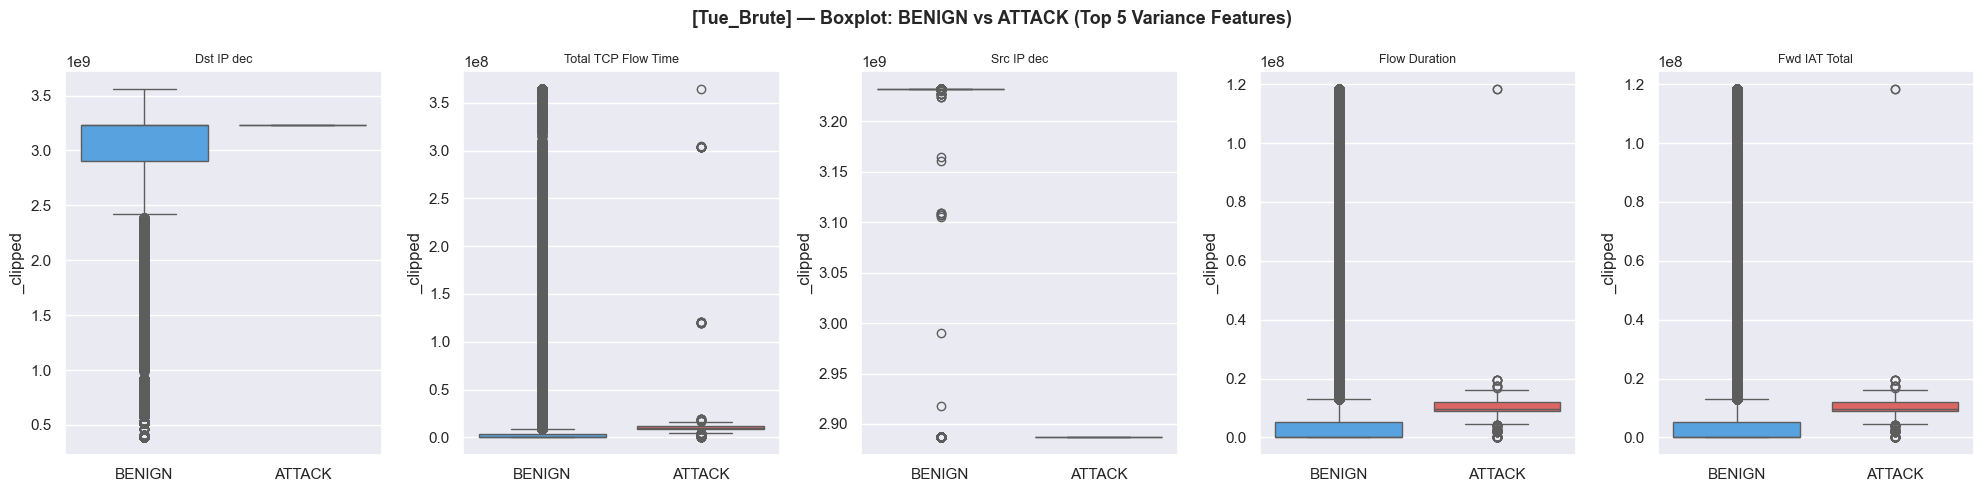

📁 Saved: 06_boxplot_Tue_Brute.png


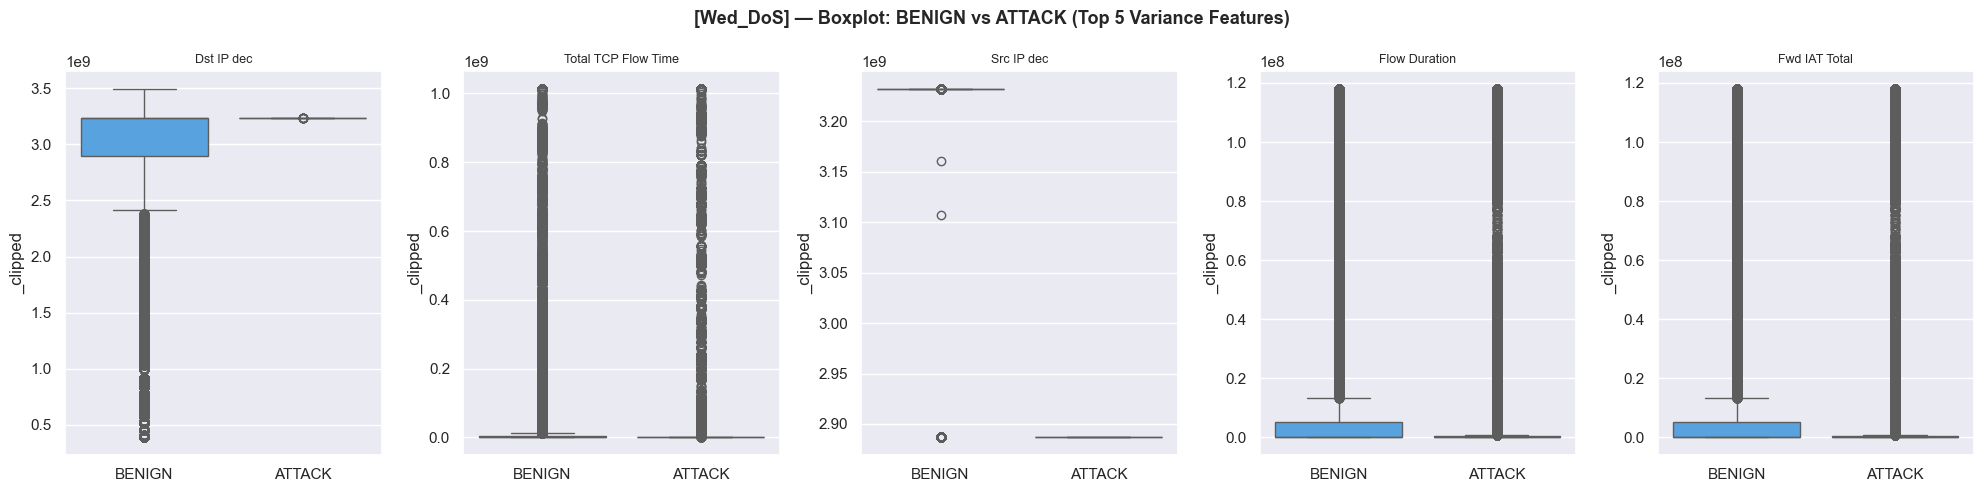

📁 Saved: 06_boxplot_Wed_DoS.png
[Thu_WebAtt] — BENIGN only, skipping boxplots


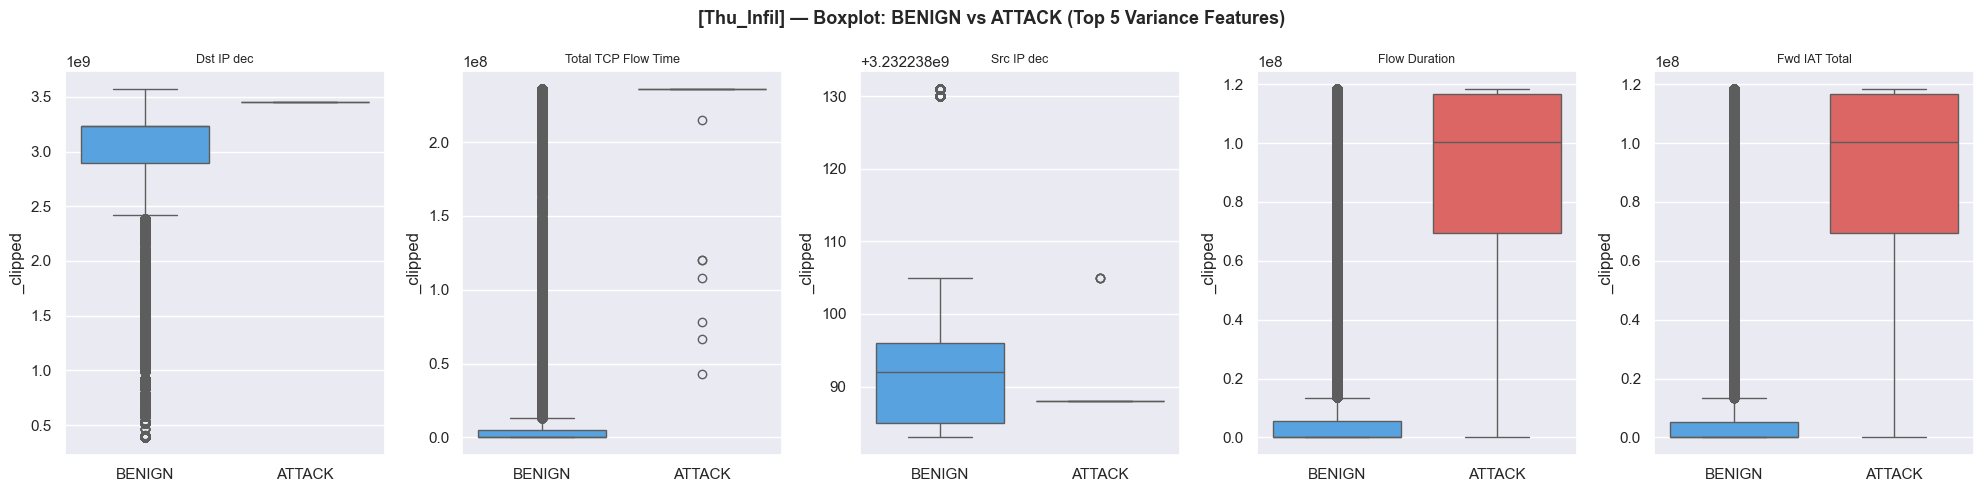

📁 Saved: 06_boxplot_Thu_Infil.png
[Fri_Morning] — BENIGN only, skipping boxplots


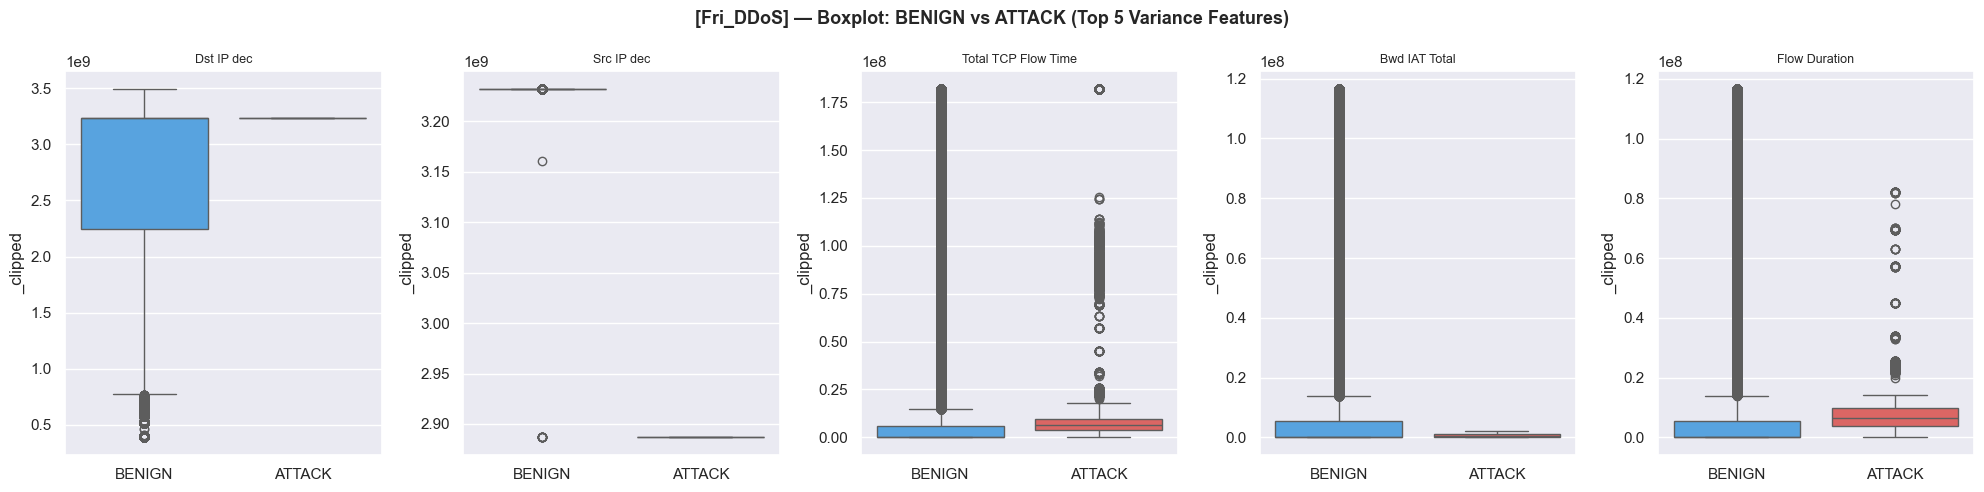

📁 Saved: 06_boxplot_Fri_DDoS.png
[Fri_PortScan] — BENIGN only, skipping boxplots


In [44]:
for tag, df in datasets.items():
    # Only files with actual attacks
    if df[TARGET_COL].nunique() < 2:
        print(f"[{tag}] — BENIGN only, skipping boxplots")
        continue

    num_df = df.select_dtypes(include=[np.number])
    top5   = num_df.var().sort_values(ascending=False).head(5).index.tolist()

    # Simplify labels: BENIGN vs ATTACK
    df_plot = df.copy()
    df_plot['Class'] = df_plot[TARGET_COL].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    for i, feat in enumerate(top5):
        clipped = df_plot[feat].clip(
            df_plot[feat].quantile(0.01),
            df_plot[feat].quantile(0.99)
        )
        df_plot['_clipped'] = clipped
        sns.boxplot(data=df_plot, x='Class', y='_clipped',
                    palette={'BENIGN': '#42A5F5', 'ATTACK': '#EF5350'},
                    ax=axes[i])
        axes[i].set_title(feat, fontsize=9)
        axes[i].set_xlabel('')

    plt.suptitle(f'[{tag}] — Boxplot: BENIGN vs ATTACK (Top 5 Variance Features)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/06_boxplot_{tag}.png", dpi=130, bbox_inches='tight')
    plt.show()
    print(f"📁 Saved: 06_boxplot_{tag}.png")

## Cell 15 — Label Encoding (Per File)

In [45]:
label_mappings = {}

for tag, df in datasets.items():
    le = LabelEncoder()
    df['label_enc'] = le.fit_transform(df[TARGET_COL])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    label_mappings[tag] = mapping
    print(f"\n  [{tag}]")
    for cls, code in mapping.items():
        print(f"      {code:2d}  →  {cls}")

# Save mappings
class NpEncoder(json.JSONEncoder):
    def default(self, o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, np.ndarray): return o.tolist()
        return super().default(o)

with open(f"{OUTPUT_DIR}/07_label_mappings.json", 'w') as f:
    json.dump(label_mappings, f, indent=2, cls=NpEncoder)


  [Mon_Benign]
       0  →  BENIGN

  [Tue_Brute]
       0  →  BENIGN
       1  →  FTP-Patator
       2  →  FTP-Patator - Attempted
       3  →  SSH-Patator
       4  →  SSH-Patator - Attempted

  [Wed_DoS]
       0  →  BENIGN
       1  →  DoS GoldenEye
       2  →  DoS GoldenEye - Attempted
       3  →  DoS Hulk
       4  →  DoS Hulk - Attempted
       5  →  DoS Slowhttptest
       6  →  DoS Slowhttptest - Attempted
       7  →  DoS Slowloris
       8  →  DoS Slowloris - Attempted
       9  →  Heartbleed

  [Thu_WebAtt]
       0  →  BENIGN

  [Thu_Infil]
       0  →  BENIGN
       1  →  Infiltration

  [Fri_Morning]
       0  →  BENIGN

  [Fri_DDoS]
       0  →  BENIGN
       1  →  DDoS

  [Fri_PortScan]


## Cell 16 — Canonical Feature Set (Model-Ready)

In [46]:
"""
Strategy:
  1. Find features common across ALL files
  2. Remove globally NZV features
  3. Remove universally high-corr redundant features
  4. Output final canonical feature list for training
"""

# Step 1: Common numeric features across all files
common_features = None
for tag, df in datasets.items():
    num_cols = set(df.select_dtypes(include=[np.number]).columns)
    num_cols.discard('label_enc')
    common_features = num_cols if common_features is None else common_features & num_cols

print(f"Step 1 — Common numeric features: {len(common_features)}")

# Step 2: Remove NZV
canonical = common_features - global_nzv
print(f"Step 2 — After removing NZV ({len(global_nzv)}): {len(canonical)}")

# Step 3: Remove high-corr redundant
canonical = canonical - universal_drop
print(f"Step 3 — After removing high-corr ({len(universal_drop)}): {len(canonical)}")

canonical_list = sorted(list(canonical))
print(f"\n✅ Final Canonical Feature Count: {len(canonical_list)}")
print("\nFeature list:")
for i, f in enumerate(canonical_list):
    print(f"  {i+1:3d}. {f}")

# Save
with open(f"{OUTPUT_DIR}/08_canonical_features.json", 'w') as f:
    json.dump(canonical_list, f, indent=2)
print(f"\n📁 Saved: 08_canonical_features.json")

Step 1 — Common numeric features: 84
Step 2 — After removing NZV (0): 84
Step 3 — After removing high-corr (0): 84

✅ Final Canonical Feature Count: 84

Feature list:
    1. ACK Flag Count
    2. Active Max
    3. Active Mean
    4. Active Min
    5. Active Std
    6. Average Packet Size
    7. Bwd Bulk Rate Avg
    8. Bwd Bytes/Bulk Avg
    9. Bwd Header Length
   10. Bwd IAT Max
   11. Bwd IAT Mean
   12. Bwd IAT Min
   13. Bwd IAT Std
   14. Bwd IAT Total
   15. Bwd Init Win Bytes
   16. Bwd PSH Flags
   17. Bwd Packet Length Max
   18. Bwd Packet Length Mean
   19. Bwd Packet Length Min
   20. Bwd Packet Length Std
   21. Bwd Packet/Bulk Avg
   22. Bwd Packets/s
   23. Bwd RST Flags
   24. Bwd Segment Size Avg
   25. Bwd URG Flags
   26. CWR Flag Count
   27. Down/Up Ratio
   28. Dst Port
   29. ECE Flag Count
   30. FIN Flag Count
   31. FWD Init Win Bytes
   32. Flow Bytes/s
   33. Flow Duration
   34. Flow IAT Max
   35. Flow IAT Mean
   36. Flow IAT Min
   37. Flow IAT Std
   3

## Cell 17 — Class Imbalance Visualization (Heatmap)

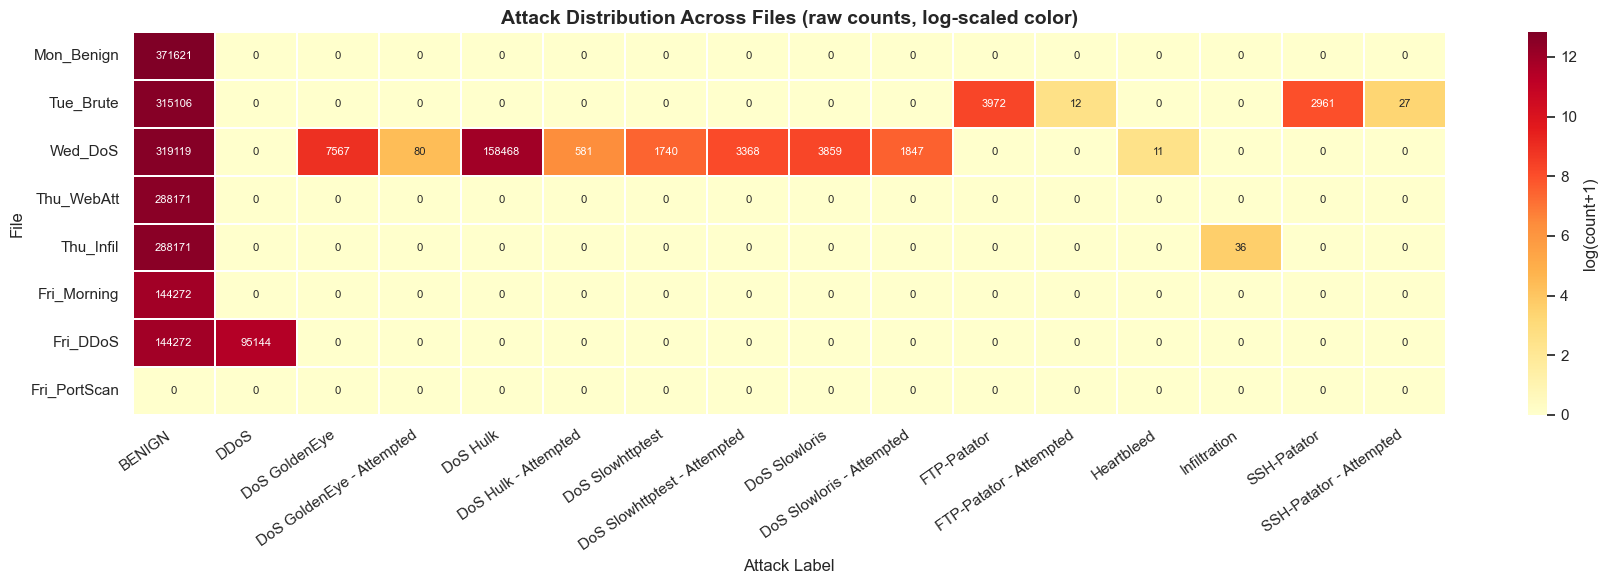

📁 Saved: 09_imbalance_heatmap.png


In [47]:
# Build a file × label count matrix
all_label_names = sorted(all_labels.unique())
imbalance_matrix = pd.DataFrame(index=list(datasets.keys()), columns=all_label_names, dtype=float)

for tag, df in datasets.items():
    for lbl in all_label_names:
        imbalance_matrix.loc[tag, lbl] = (df[TARGET_COL] == lbl).sum()

imbalance_matrix = imbalance_matrix.fillna(0).astype(float)

# Log scale for visibility
log_matrix = np.log1p(imbalance_matrix)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(log_matrix, annot=imbalance_matrix.astype(int), fmt='d',
            cmap='YlOrRd', linewidths=0.3, ax=ax,
            annot_kws={'size': 8},
            cbar_kws={'label': 'log(count+1)'})
ax.set_title('Attack Distribution Across Files (raw counts, log-scaled color)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Label')
ax.set_ylabel('File')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_imbalance_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: 09_imbalance_heatmap.png")

## Cell 18 — Autoencoder Baseline Data (Monday BENIGN Only)

In [48]:
"""
For the LSTM Autoencoder (zero-day detection), we train ONLY on normal traffic.
Monday file is perfect — it's 100% BENIGN.
This cell exports a clean BENIGN-only dataset using canonical features.
"""

AE_TAG = 'Mon_Benign'

if AE_TAG in datasets:
    df_ae = datasets[AE_TAG]
    benign_only = df_ae[df_ae[TARGET_COL] == 'BENIGN']

    # Use only canonical features
    ae_features = [f for f in canonical_list if f in benign_only.columns]
    ae_export = benign_only[ae_features].copy()

    print(f"Autoencoder training data (BENIGN only):")
    print(f"  Rows    : {len(ae_export):,}")
    print(f"  Features: {len(ae_features)}")
    print(f"  Shape   : {ae_export.shape}")

    # Feature range check
    print(f"\n  Feature value ranges (sample):")
    print(ae_export.describe().T[['min','max','mean','std']].head(10).to_string())

    ae_export.to_csv(f"{OUTPUT_DIR}/10_autoencoder_benign_train.csv", index=False)
    print(f"\n📁 Saved: 10_autoencoder_benign_train.csv")
else:
    print(f"⚠️  {AE_TAG} not in datasets — check FILE_MAP")

Autoencoder training data (BENIGN only):
  Rows    : 371,621
  Features: 84
  Shape   : (371621, 84)

  Feature value ranges (sample):
                            min             max         mean           std
ACK Flag Count           0.0000     511681.0000      28.3230     2466.2885
Active Max               0.0000  101659665.0000  239421.7962  1281928.5775
Active Mean              0.0000  101659665.0000  124801.4424   777662.4853
Active Min               0.0000  101659665.0000   86642.5531   680661.5087
Active Std               0.0000   64349504.5000   66188.8599   490851.9072
Average Packet Size      0.0000       1809.3060     139.0955      164.9124
Bwd Bulk Rate Avg        0.0000 1127000000.0000  555321.2290  5949465.8495
Bwd Bytes/Bulk Avg       0.0000  156761876.0000    3891.9032   318201.2542
Bwd Header Length   -32764.0000      32632.0000     195.7978      886.1474
Bwd IAT Max              0.0000  119974145.0000 5659117.8828 15848721.7992

📁 Saved: 10_autoencoder_benign_train.cs

## Cell 19 — Reconstruction Error Baseline (Statistical)

In [49]:
"""
Compute per-feature mean and std on Monday BENIGN data.
This gives a statistical baseline for what 'normal' looks like —
useful for setting anomaly thresholds in the Autoencoder later.
"""

if AE_TAG in datasets:
    benign_stats = ae_export.agg(['mean', 'std', 'min', 'max']).T
    benign_stats['cv'] = (benign_stats['std'] / (benign_stats['mean'].abs() + 1e-9)).round(4)

    print("BENIGN traffic feature statistics (top 15 most variable):")
    print(benign_stats.sort_values('cv', ascending=False).head(15).to_string())

    benign_stats.to_csv(f"{OUTPUT_DIR}/11_benign_feature_stats.csv")
    print("\n📁 Saved: 11_benign_feature_stats.csv")

BENIGN traffic feature statistics (top 15 most variable):
                                    mean            std    min              max       cv
Subflow Bwd Packets               0.0000         0.0046 0.0000           1.0000 215.5167
Total Length of Bwd Packet    25530.6212   3194852.2913 0.0000   655452323.0000 125.1381
ACK Flag Count                   28.3230      2466.2885 0.0000      511681.0000  87.0772
Total Bwd packets                16.7416      1401.0815 0.0000      291922.0000  83.6888
Bwd Bytes/Bulk Avg             3891.9032    318201.2542 0.0000   156761876.0000  81.7598
Total Fwd Packet                 14.6388      1065.6410 0.0000      219759.0000  72.7959
ECE Flag Count                    0.0004         0.0270 0.0000           2.0000  72.5790
CWR Flag Count                    0.0002         0.0155 0.0000           2.0000  66.0960
Bwd Packet/Bulk Avg               2.1290       117.8275 0.0000       56120.0000  55.3432
Fwd Bulk Rate Avg            214238.4072   4366861.3

## Cell 20 — Export Clean Samples for Quick Prototyping (All Files)

In [50]:
"""
Export a balanced sample (5k benign + all attacks, up to 5k per attack type)
for each file, using canonical features only.
Use these for quick model architecture testing before full training.
"""

PROTO_BENIGN   = 5000
PROTO_PER_ATK  = 5000

for tag, df in datasets.items():
    feat_avail = [f for f in canonical_list if f in df.columns]

    benign_df = df[df[TARGET_COL] == 'BENIGN'].sample(
        min(PROTO_BENIGN, (df[TARGET_COL] == 'BENIGN').sum()), random_state=42)

    attack_dfs = []
    for lbl in df[TARGET_COL].unique():
        if lbl == 'BENIGN':
            continue
        atk_df = df[df[TARGET_COL] == lbl]
        attack_dfs.append(atk_df.sample(min(PROTO_PER_ATK, len(atk_df)), random_state=42))

    proto_df = pd.concat([benign_df] + attack_dfs, ignore_index=True)
    proto_df = proto_df[feat_avail + [TARGET_COL, 'label_enc']].sample(frac=1, random_state=42)

    out_path = f"{OUTPUT_DIR}/12_proto_{tag}.csv"
    proto_df.to_csv(out_path, index=False)
    print(f"  [{tag:15s}]  {len(proto_df):,} rows → {out_path}")

print("\n📁 All prototype CSVs saved!")

  [Mon_Benign     ]  5,000 rows → ./eda_outputs/12_proto_Mon_Benign.csv
  [Tue_Brute      ]  11,972 rows → ./eda_outputs/12_proto_Tue_Brute.csv
  [Wed_DoS        ]  26,486 rows → ./eda_outputs/12_proto_Wed_DoS.csv
  [Thu_WebAtt     ]  5,000 rows → ./eda_outputs/12_proto_Thu_WebAtt.csv
  [Thu_Infil      ]  5,036 rows → ./eda_outputs/12_proto_Thu_Infil.csv
  [Fri_Morning    ]  5,000 rows → ./eda_outputs/12_proto_Fri_Morning.csv
  [Fri_DDoS       ]  10,000 rows → ./eda_outputs/12_proto_Fri_DDoS.csv
  [Fri_PortScan   ]  0 rows → ./eda_outputs/12_proto_Fri_PortScan.csv

📁 All prototype CSVs saved!


## Cell 21 — EDA Summary Report

In [51]:
print("\n" + "═"*70)
print("  NeuralSOC EDA — FINAL SUMMARY")
print("═"*70)

total_rows = sum(len(df) for df in datasets.values())
print(f"\n  Total samples across all files : {total_rows:,}")
print(f"  Unique attack labels           : {len(global_counts) - 1}")
print(f"  Canonical feature count        : {len(canonical_list)}")
print(f"  Globally NZV features dropped  : {len(global_nzv)}")
print(f"  Universally redundant dropped  : {len(universal_drop)}")

print("\n  Files processed:")
for tag, df in datasets.items():
    print(f"    [{tag:15s}]  {len(df):>9,} rows  |  "
          f"{df[TARGET_COL].nunique()} classes")

print("\n  Outputs saved to:", os.path.abspath(OUTPUT_DIR))
print("\n  Key files for training pipeline:")
print("    → 08_canonical_features.json       : Use this feature list for ALL models")
print("    → 10_autoencoder_benign_train.csv  : LSTM Autoencoder training data")
print("    → 12_proto_*.csv                   : Quick prototyping datasets")
print("    → 07_label_mappings.json           : Label → int mappings")
print("\n" + "═"*70)
print("  ✅ EDA Complete — Ready for model training!")
print("═"*70)


══════════════════════════════════════════════════════════════════════
  NeuralSOC EDA — FINAL SUMMARY
══════════════════════════════════════════════════════════════════════

  Total samples across all files : 2,150,405
  Unique attack labels           : 15
  Canonical feature count        : 84
  Globally NZV features dropped  : 0
  Universally redundant dropped  : 0

  Files processed:
    [Mon_Benign     ]    371,621 rows  |  1 classes
    [Tue_Brute      ]    322,078 rows  |  5 classes
    [Wed_DoS        ]    496,640 rows  |  10 classes
    [Thu_WebAtt     ]    288,171 rows  |  1 classes
    [Thu_Infil      ]    288,207 rows  |  2 classes
    [Fri_Morning    ]    144,272 rows  |  1 classes
    [Fri_DDoS       ]    239,416 rows  |  2 classes
    [Fri_PortScan   ]          0 rows  |  0 classes

  Outputs saved to: d:\VSC\GitHub\NeuralSOC\notebooks\eda_outputs

  Key files for training pipeline:
    → 08_canonical_features.json       : Use this feature list for ALL models
    → 10_au

In [54]:
"""
Export fully processed datasets to data/processed/
One CSV per day-file, with:
  - numeric conversion applied
  - NaN/inf cleaned
  - label_enc column included
  - canonical features only
"""

PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

for tag, df in datasets.items():
    feat_avail = [f for f in canonical_list if f in df.columns]
    export_cols = feat_avail + [TARGET_COL, 'label_enc']

    out_path = os.path.join(PROCESSED_DIR, f"{tag}.csv")
    df[export_cols].to_csv(out_path, index=False)
    print(f"  [{tag:15s}]  {len(df):,} rows  →  {out_path}")

print(f"\n✅ All processed files saved to: {os.path.abspath(PROCESSED_DIR)}")

  [Mon_Benign     ]  371,621 rows  →  ../data/processed\Mon_Benign.csv
  [Tue_Brute      ]  322,078 rows  →  ../data/processed\Tue_Brute.csv
  [Wed_DoS        ]  496,640 rows  →  ../data/processed\Wed_DoS.csv
  [Thu_WebAtt     ]  288,171 rows  →  ../data/processed\Thu_WebAtt.csv
  [Thu_Infil      ]  288,207 rows  →  ../data/processed\Thu_Infil.csv
  [Fri_Morning    ]  144,272 rows  →  ../data/processed\Fri_Morning.csv
  [Fri_DDoS       ]  239,416 rows  →  ../data/processed\Fri_DDoS.csv
  [Fri_PortScan   ]  0 rows  →  ../data/processed\Fri_PortScan.csv

✅ All processed files saved to: d:\VSC\GitHub\NeuralSOC\data\processed
